This notebook contains training ONLY the parameters of the single-compartment neuron with Pospischil-type channels. We switched off the nerual ODE augmentation here, so the results can play as a benchmark for our models. We don't use modified channels either. We test all 4 cells.

In [1]:
import os
os.environ['XLA_FLAGS'] = '--xla_cpu_use_thunk_runtime=false'
os.environ["XLA_PYTHON_CLIENT_MEM_FRACTION"] = "0.95"

%load_ext autoreload
%autoreload 2


from jax import config
config.update("jax_enable_x64", True)


import matplotlib.pyplot as plt
import jax
import jax.numpy as jnp
import numpy as np
import optax
import jaxley as jx


import equinox as eqx
import flax.nnx as nnx

In [2]:
t_max = 90.0
cut = 1500

setup = "488683425"
# setup = "485574832"
# setup = "480353286"
# setup = "473601979"


# Define target
from voltage_fitting.build_simulator import (
    get_experimental_data,
)
t, v_data, i_amp = get_experimental_data(setup, cut, t_max)
v_data = jnp.asarray(v_data[None,])

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


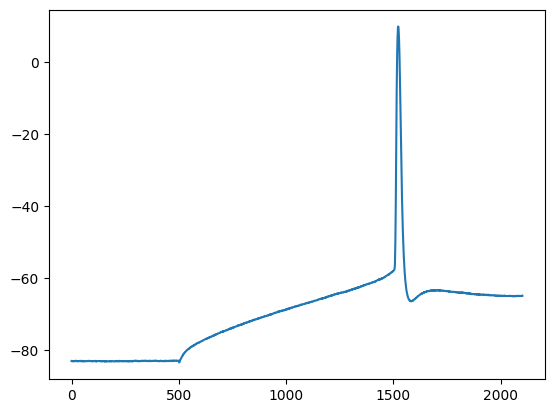

In [3]:
plt.plot(v_data[0])

dt_difference 5.0
Amplitude stimulus: 0.20999999344348907


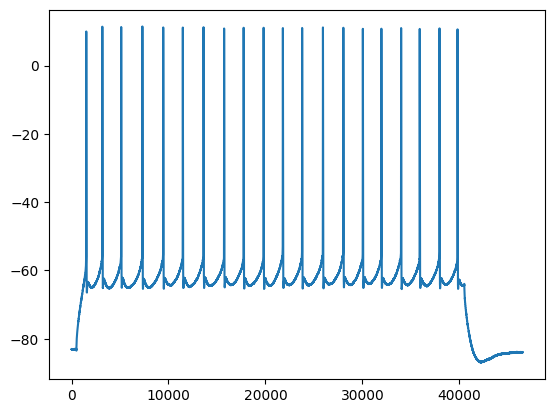

In [4]:
t_max_long = 1199.9376

t, v_data_long, i_amp = get_experimental_data(setup, cut, t_max_long)
v_data_long = jnp.asarray(v_data_long[None,])

plt.plot(v_data_long[0])

In [5]:
# Define the single-compartment cell to train
from voltage_fitting.single_build_simulator import (
    setup_Na_K_simulator,
    setup_Na_K_simulator_step,
    build_Na_K_cell,
    set_setup,
    get_Na_K_bounds,
    transform_uniform_to_normal,
    get_prior
)

from voltage_fitting.loss_util import (
    get_scaled_loss,
)

seed = 7

rng_key = jax.random.PRNGKey(seed)

all_setup = set_setup(setup)
cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup["length"], use_CaT=True, use_CaL=False, use_Km=True)
simulate_single = setup_Na_K_simulator(cell, cut, t_max, all_setup["v_init"], i_amp)


# Sampling parameters
_, lower, upper = get_Na_K_bounds()

transform_params, inv_transform_params = transform_uniform_to_normal(lower, upper)
sample_prior = get_prior(lower, upper, transform_params)

init_rng_key, sampling_rng_key = jax.random.split(rng_key)

# Sample 1 initialization randomly.
sampled_params = sample_prior(init_rng_key)
inv_sampled_params = inv_transform_params(sampled_params)

v_single = simulate_single(inv_sampled_params, v_data[0], gating = False)[0]

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

Added 1 external_states. See `.externals` for details.
Added 1 recordings. See `.recordings` for details.
Number of parameters: 11


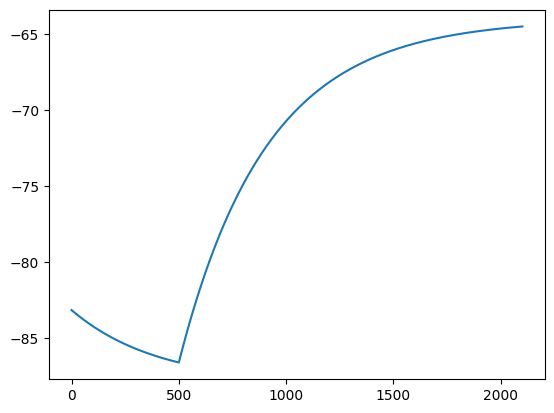

In [6]:
plt.plot(v_single[0])

In [7]:
# Define the networks
@jax.jit
def normalize_voltage(v):
    # Normalize voltage between -1 and 1
    return 2 * (v - jnp.min(v_data)) / (jnp.max(v_data) - jnp.min(v_data)) - 1

@jax.jit
def softsign_transform(v):
    return v / (1 + jnp.abs(v))

@jax.jit
def tempered_tanh(v, scale=0.05):
    return jnp.tanh(scale * v)

In [8]:
class ParameterModel(eqx.Module):
    channel_params_normal: jax.Array

    def __init__(self, *, init_params):
        self.channel_params_normal = init_params

In [11]:
dt = 0.025
max_add_current = 1.0

def simulate_full_trace(initial_state, step_fn, current, time_vec, x_o, thr = None):
    def cond_fn(carry):
        t, _, _, diff = carry
        keep_running = t < len(time_vec)
    
        if thr is None:
            return keep_running
        else:
            return jnp.logical_and(keep_running, diff < thr)

    def body_fn(carry):
        t, state, new_recs, diff = carry
        state, rec = step_fn(state, current[t])

        rec_voltage = rec[0]

        new_recs = new_recs.at[t].set(rec_voltage)

        new_diff = diff + (rec_voltage - x_o[t + 1])**2

        return (t + 1, state, new_recs, new_diff)

    # Initialize buffers
    recs = jnp.full((len(time_vec),), jnp.nan)

    carry = (0, initial_state, recs, 0.0)

    final_carry = eqx.internal.while_loop(
        cond_fun=cond_fn,
        body_fun=body_fn,
        init_val=carry,
        max_steps=len(time_vec),
        kind="bounded"
    )

    _, _, recs, _ = final_carry

    return recs

In [12]:
cost_fn_power = 1.0
scale = 0.05

def loss_fn(model, all_setup, t_max, i_amp, v_data, thr=300, dtw_reg = 1.0, spike_reg = 0.0, sse_reg = 0.0):

    params = inv_transform_params(model.channel_params_normal)

    # Rebuild the simulator with new cell
    initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, gating = False, params = params)

    # Run simulation
    preds = simulate_full_trace(
        initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
    )

    preds = preds.squeeze()
    v_data = v_data.squeeze()

    sse_loss = jnp.sum(jnp.nan_to_num((preds - v_data) ** 2, nan=0.0))

    scaled_loss = get_scaled_loss(v_data, preds, cost_fn_power, scale)

    spike_loss = jnp.abs(jnp.max(preds) - jnp.max(v_data))
    
    return scaled_loss * dtw_reg + sse_loss * sse_reg + spike_loss * spike_reg

In [13]:
np.random.seed(42)
n_particles = 300

rngs = nnx.Rngs(1)
key = jax.random.PRNGKey(0)
keys = jax.random.split(jax.random.PRNGKey(0), num=n_particles)


all_setup = set_setup(setup)

thr = None


initial_lr = 15e-3
decay_factor = 0.99
transition_steps = 1  # decay after every epoch
#decay_until = 400  # after x epochs, stop decaying
decay_start = 1
decay_end = 350 


opt_params = jax.vmap(sample_prior)(
    jax.random.split(init_rng_key, n_particles)
)


def initialize_model(init_params):
    model = ParameterModel(init_params=init_params)
    return model


models = jax.vmap(initialize_model)(opt_params)

raw_schedule = optax.exponential_decay(
    init_value=initial_lr,
    transition_steps=transition_steps,
    decay_rate=decay_factor,
    staircase=True,
)


def custom_schedule(step):
    # Epochs before decay_start → constant
    lr = initial_lr

    # Epochs between decay_start and decay_end → decay
    decay_steps = jnp.clip(step - decay_start, 0, decay_end - decay_start)
    lr = jnp.where(
        step < decay_start,
        initial_lr,
        raw_schedule(decay_steps)
    )

    # After decay_end → freeze at last decayed value
    final_lr = raw_schedule(decay_end - decay_start)
    lr = jnp.where(step > decay_end, final_lr, lr)

    return lr


adam_optimizer = optax.adam(learning_rate=custom_schedule)
lbfgs_optimizer = optax.chain(
            optax.scale_by_lbfgs(memory_size = 6), #8
            optax.scale(-1e-3), #0.3
        )
adamw_optimizer = optax.adamw(
    learning_rate=custom_schedule, 
    weight_decay=1e-4              
)

def init_adam_optimizer_state(model):
    return adam_optimizer.init(eqx.filter(model, eqx.is_inexact_array))

def init_lbfgs_optimizer_state(model):
    return lbfgs_optimizer.init(eqx.filter(model, eqx.is_inexact_array)) 

def init_adamw_optimizer_state(model):
    return adamw_optimizer.init(eqx.filter(model, eqx.is_inexact_array))


optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_adam_optimizer_state)(models)
# optimizer_states = jax.vmap(init_lbfgs_optimizer_state)(models)

def simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, v_data, thr, dtw_reg = 1.0, spike_reg = 0.0, sse_reg = 0.0)
        return loss

def fine_simulation_loss_fn(all_params):
        loss = loss_fn(all_params, all_setup, t_max, i_amp, v_data, thr, dtw_reg = 0.0, spike_reg = 0.0, sse_reg = 1.0)
        return loss



grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(simulation_loss_fn)))
fine_grad_fn = nnx.jit(jax.vmap(nnx.value_and_grad(fine_simulation_loss_fn)))

cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

cell.delete_stimuli()
cell.delete_recordings()

current = jx.step_current(50, 1000, i_amp, dt, t_max)
current = current[cut:]

cell.stimulate(current, verbose = False)
cell.record(verbose = False)
# cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
# cell.soma.branch(0).comp(0).record(verbose = False)
cell.set("v", all_setup['v_init'])
cell.init_states()

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

In [14]:
def clip_channel_gradients(grads, max_norm=10.0, eps=1e-8):
    def clip_leaf(grad):
        flat = grad.reshape((grad.shape[0], -1)) if grad.ndim > 1 else grad[:, None]
        norms = jnp.linalg.norm(flat, axis=1, keepdims=True)
        scaling = jnp.minimum(1.0, max_norm / (norms + eps))
        while scaling.ndim < grad.ndim:
            scaling = scaling[..., None]
        return grad * scaling

    clipped = clip_leaf(grads.channel_params_normal)
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, clipped)
    return grads


def normalize_channel_gradients(grads, beta=1.0, eps=1e-8):
    norms = jnp.linalg.norm(grads.channel_params_normal, axis=1, keepdims=True)
    normalized = grads.channel_params_normal / (norms ** beta + eps)

    # Replace only the channel_params_normal field
    grads = eqx.tree_at(lambda g: g.channel_params_normal, grads, normalized)
    return grads

def scale_grads(grads, lr_main, lr_channel):
    grads_channel_scaled = grads.channel_params_normal * lr_channel

    return eqx.tree_at(
        lambda g: g.channel_params_normal,
        grads_channel_scaled
    )

In [15]:
num_epochs = 300
mean_losses = []
best_losses = jnp.full((n_particles,), jnp.inf)
best_models = models  # Start with the initial models as best
grads_list = []

for epoch in range(num_epochs):

    # if epoch == 370: #370
    #     optimizer = optax.chain(
    #         optax.scale_by_lbfgs(memory_size = 8), #8
    #         optax.scale(-0.2e-1), #0.3
    #     )
    #     optimizer_state = nnx.Optimizer(optimizer_state.model, optimizer)
    

    loss, grads = grad_fn(models)
    grads_list.append(grads)
    
    grads = clip_channel_gradients(grads, max_norm=10.0, eps=1e-8)
    # grads = scale_grads(grads, lr_main=1e-2, lr_channel=1.0)



    improved = loss < best_losses
    best_losses = jnp.where(improved, loss, best_losses)

    def replace_if_improved(new, old):
        mask = improved.reshape((-1,) + (1,) * (new.ndim - 1))
        return jnp.where(mask, new, old)

    best_models = jax.tree_util.tree_map(replace_if_improved, models, best_models)

    mean_losses.append(jnp.mean(loss))

    updates, optimizer_states = jax.vmap(lambda g, s, m: adam_optimizer.update(g, s, m, step = epoch))(grads, optimizer_states, models)
    models = jax.vmap(eqx.apply_updates)(models, updates)

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Mean Loss: {jnp.mean(loss):.6f}, Median Loss {jnp.median(loss):.6f}, Min Loss: {jnp.min(loss):.6f}")

        print('Max gradient norm: ', jnp.max(jnp.linalg.norm(grads.channel_params_normal, axis=1)), ', Min gradient norm: ', jnp.min(jnp.linalg.norm(grads.channel_params_normal, axis=1)))

/Users/moldor/anaconda3/envs/jaxley_env/lib/python3.12/site-packages/jax/_src/ops/scatter.py:93: FutureWarning: scatter inputs have incompatible types: cannot safely cast value from dtype=float64 to dtype=float32 with jax_numpy_dtype_promotion='standard'. In future JAX releases this will result in an error.
  warnings.warn(


Epoch 0, Mean Loss: 160.550133, Median Loss 166.462903, Min Loss: 42.119113
Max gradient norm:  9.999999999981048 , Min gradient norm:  2.1752071840495937
Epoch 10, Mean Loss: 150.256680, Median Loss 157.554026, Min Loss: 33.108624
Max gradient norm:  9.999999999988479 , Min gradient norm:  0.6782310514032026
Epoch 20, Mean Loss: 143.783980, Median Loss 150.298691, Min Loss: 34.885083
Max gradient norm:  9.999999999992108 , Min gradient norm:  0.2907058877248939
Epoch 30, Mean Loss: 139.289080, Median Loss 143.292419, Min Loss: 39.337299
Max gradient norm:  9.99999999999192 , Min gradient norm:  0.1058805388921838
Epoch 40, Mean Loss: 134.643497, Median Loss 137.857513, Min Loss: 48.422793
Max gradient norm:  9.999999999991932 , Min gradient norm:  0.3748192694560687
Epoch 50, Mean Loss: 130.482292, Median Loss 131.726667, Min Loss: 37.223281
Max gradient norm:  9.999999999990472 , Min gradient norm:  0.1263492930356197
Epoch 60, Mean Loss: 127.532224, Median Loss 128.343151, Min Loss:

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

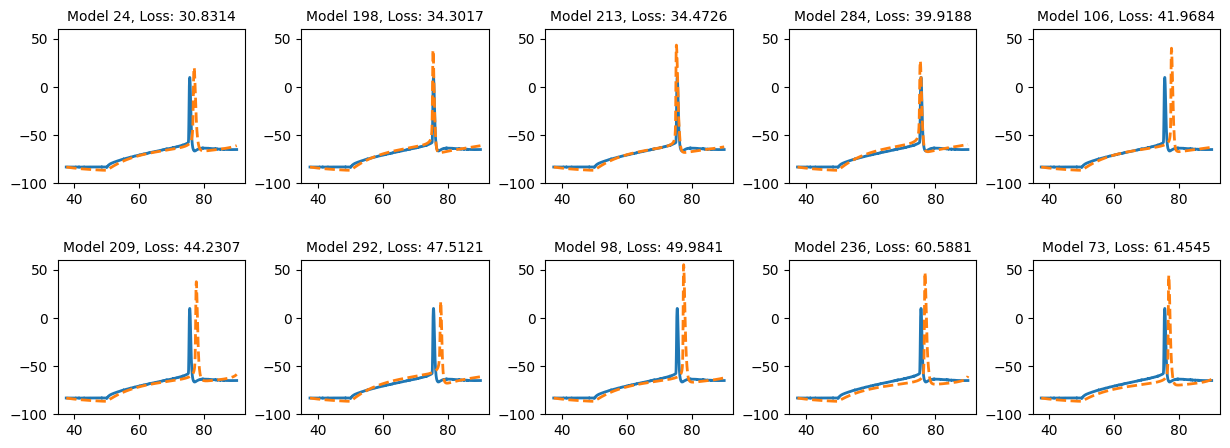

In [ ]:
#25: t = 90.0, CaT + Km
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

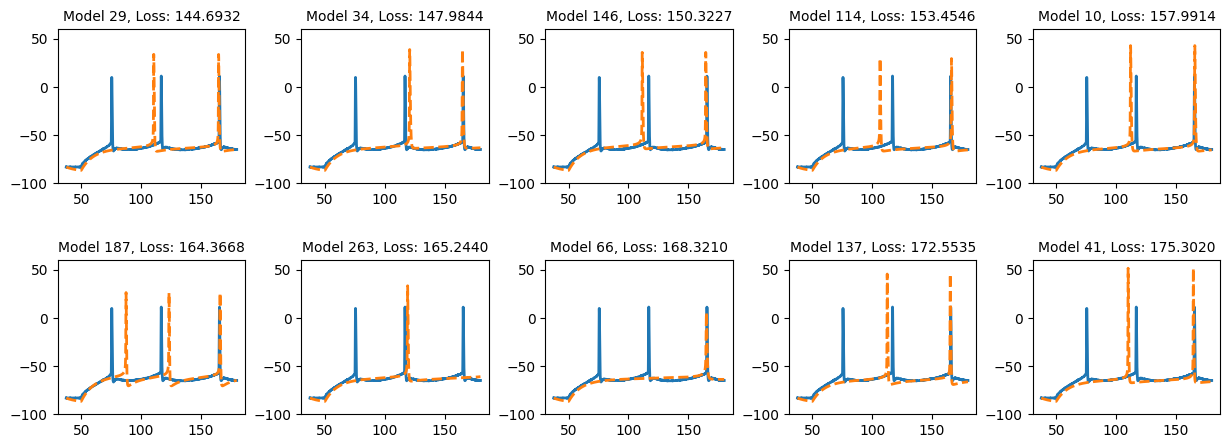

In [ ]:
#25: t = 180.0, CaT + Km
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

Extrapolation:

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

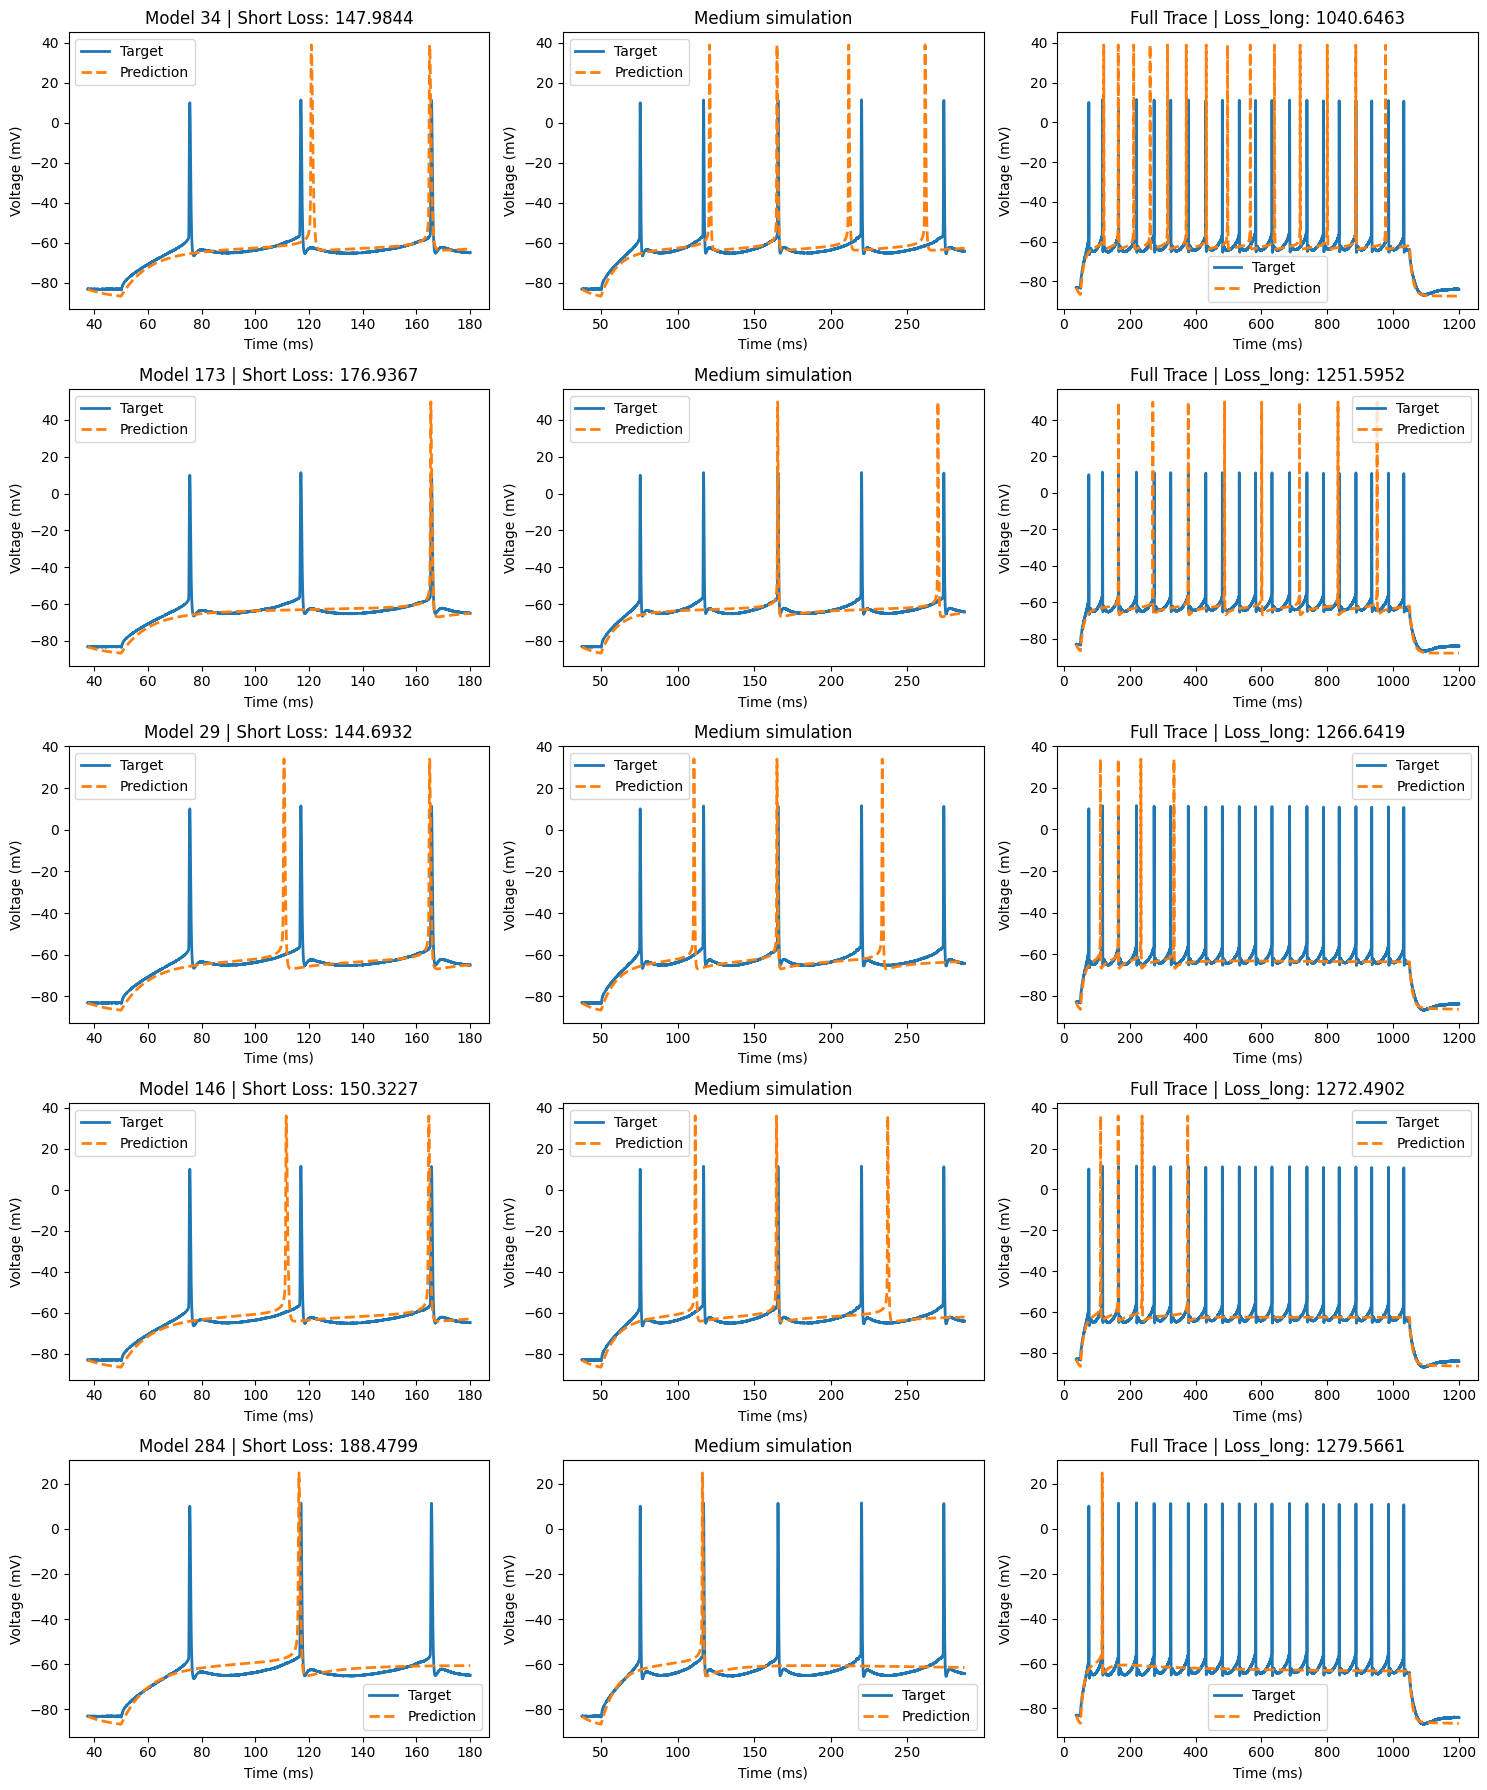

In [ ]:
inds = np.argsort(best_losses)[:20]  # best 20 models

loss_long_list = []
results = []

for idx in range(20):
    model = jax.tree_util.tree_map(lambda x: x[inds[idx]], best_models)

    opt_inv_params = inv_transform_params(model.channel_params_normal)
    cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

    cell.delete_stimuli()
    cell.delete_recordings()

    current = jx.step_current(50, 1000, i_amp, dt, t_max)
    current = current[cut:]

    cell.stimulate(current, verbose = False)
    cell.record(verbose = False)
    # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
    # cell.soma.branch(0).comp(0).record(verbose = False)
    cell.set("v", all_setup['v_init'])
    cell.init_states()

    # Simulator
    initial_state, step_fn, current, time_vec_long = setup_Na_K_simulator_step(cell, cut, t_max_long, all_setup["v_init"], i_amp, params = opt_inv_params)

    # Run simulation
    final_preds_long = simulate_full_trace(
        initial_state, step_fn, current, time_vec_long, v_data_long.squeeze(), thr
    )

    loss = simulation_loss_fn(model)
    loss_long = get_scaled_loss(v_data_long[0], final_preds_long, cost_fn_power, scale)

    loss_long_list.append(loss_long)
    results.append((loss, loss_long, final_preds_long, time_vec_long, inds[idx]))

# --- Sort by loss_long and take top 5 ---
sorted_results = sorted(results, key=lambda x: x[1])[:5]

fig, axs = plt.subplots(5, 3, figsize=(15, 18))

for row, (loss, loss_long, final_preds_long, time_vec_long, model_idx) in enumerate(sorted_results):
    # --- Short trace ---
    axs[row, 0].plot(time_vec_long[:5702], v_data_long[0][:5702], label="Data target", linewidth=2)
    axs[row, 0].plot(time_vec_long[:5702], final_preds_long[:5702], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 0].set_title(f"Model {model_idx} | Short Loss: {loss:.4f}")
    axs[row, 0].set_xlabel("Time (ms)")
    axs[row, 0].set_ylabel("Voltage (mV)")
    axs[row, 0].legend(["Target", "Prediction"])

    # --- Medium trace ---
    axs[row, 1].plot(time_vec_long[:10000], v_data_long[0][:10000], label="Data target", linewidth=2)
    axs[row, 1].plot(time_vec_long[:10000], final_preds_long[:10000], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 1].set_title(f"Medium simulation")
    axs[row, 1].set_xlabel("Time (ms)")
    axs[row, 1].set_ylabel("Voltage (mV)")
    axs[row, 1].legend(["Target", "Prediction"])

    # --- Full trace ---
    axs[row, 2].plot(time_vec_long, v_data_long[0], label="Data target", linewidth=2)
    axs[row, 2].plot(time_vec_long, final_preds_long, label="Prediction", linestyle="--", linewidth=2)
    axs[row, 2].set_title(f"Full Trace | Loss_long: {loss_long:.4f}")
    axs[row, 2].set_xlabel("Time (ms)")
    axs[row, 2].set_ylabel("Voltage (mV)")
    axs[row, 2].legend(["Target", "Prediction"])

plt.tight_layout()
plt.show()

For the paper

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

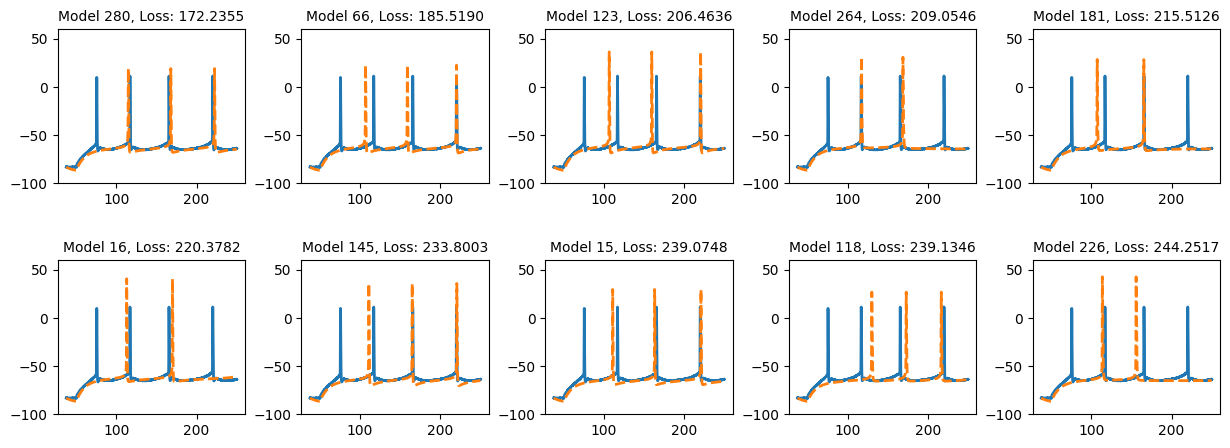

In [ ]:
#25: t = 250.0, CaT + Km
inds = np.argsort(best_losses)

best_losses_10 = []
best_preds_10 = []

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        best_losses_10.append(best_losses[inds[0 + i*5+j]])
        best_preds_10.append(final_preds)
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)


np.save('../results/no_nn_catkm_25_250_preds.npy', np.array(best_preds_10))
np.save('../results/no_nn_catkm_25_250_losses.npy', np.array(best_losses_10))
np.save('../results/v_data_25_250.npy', np.array(v_data))

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

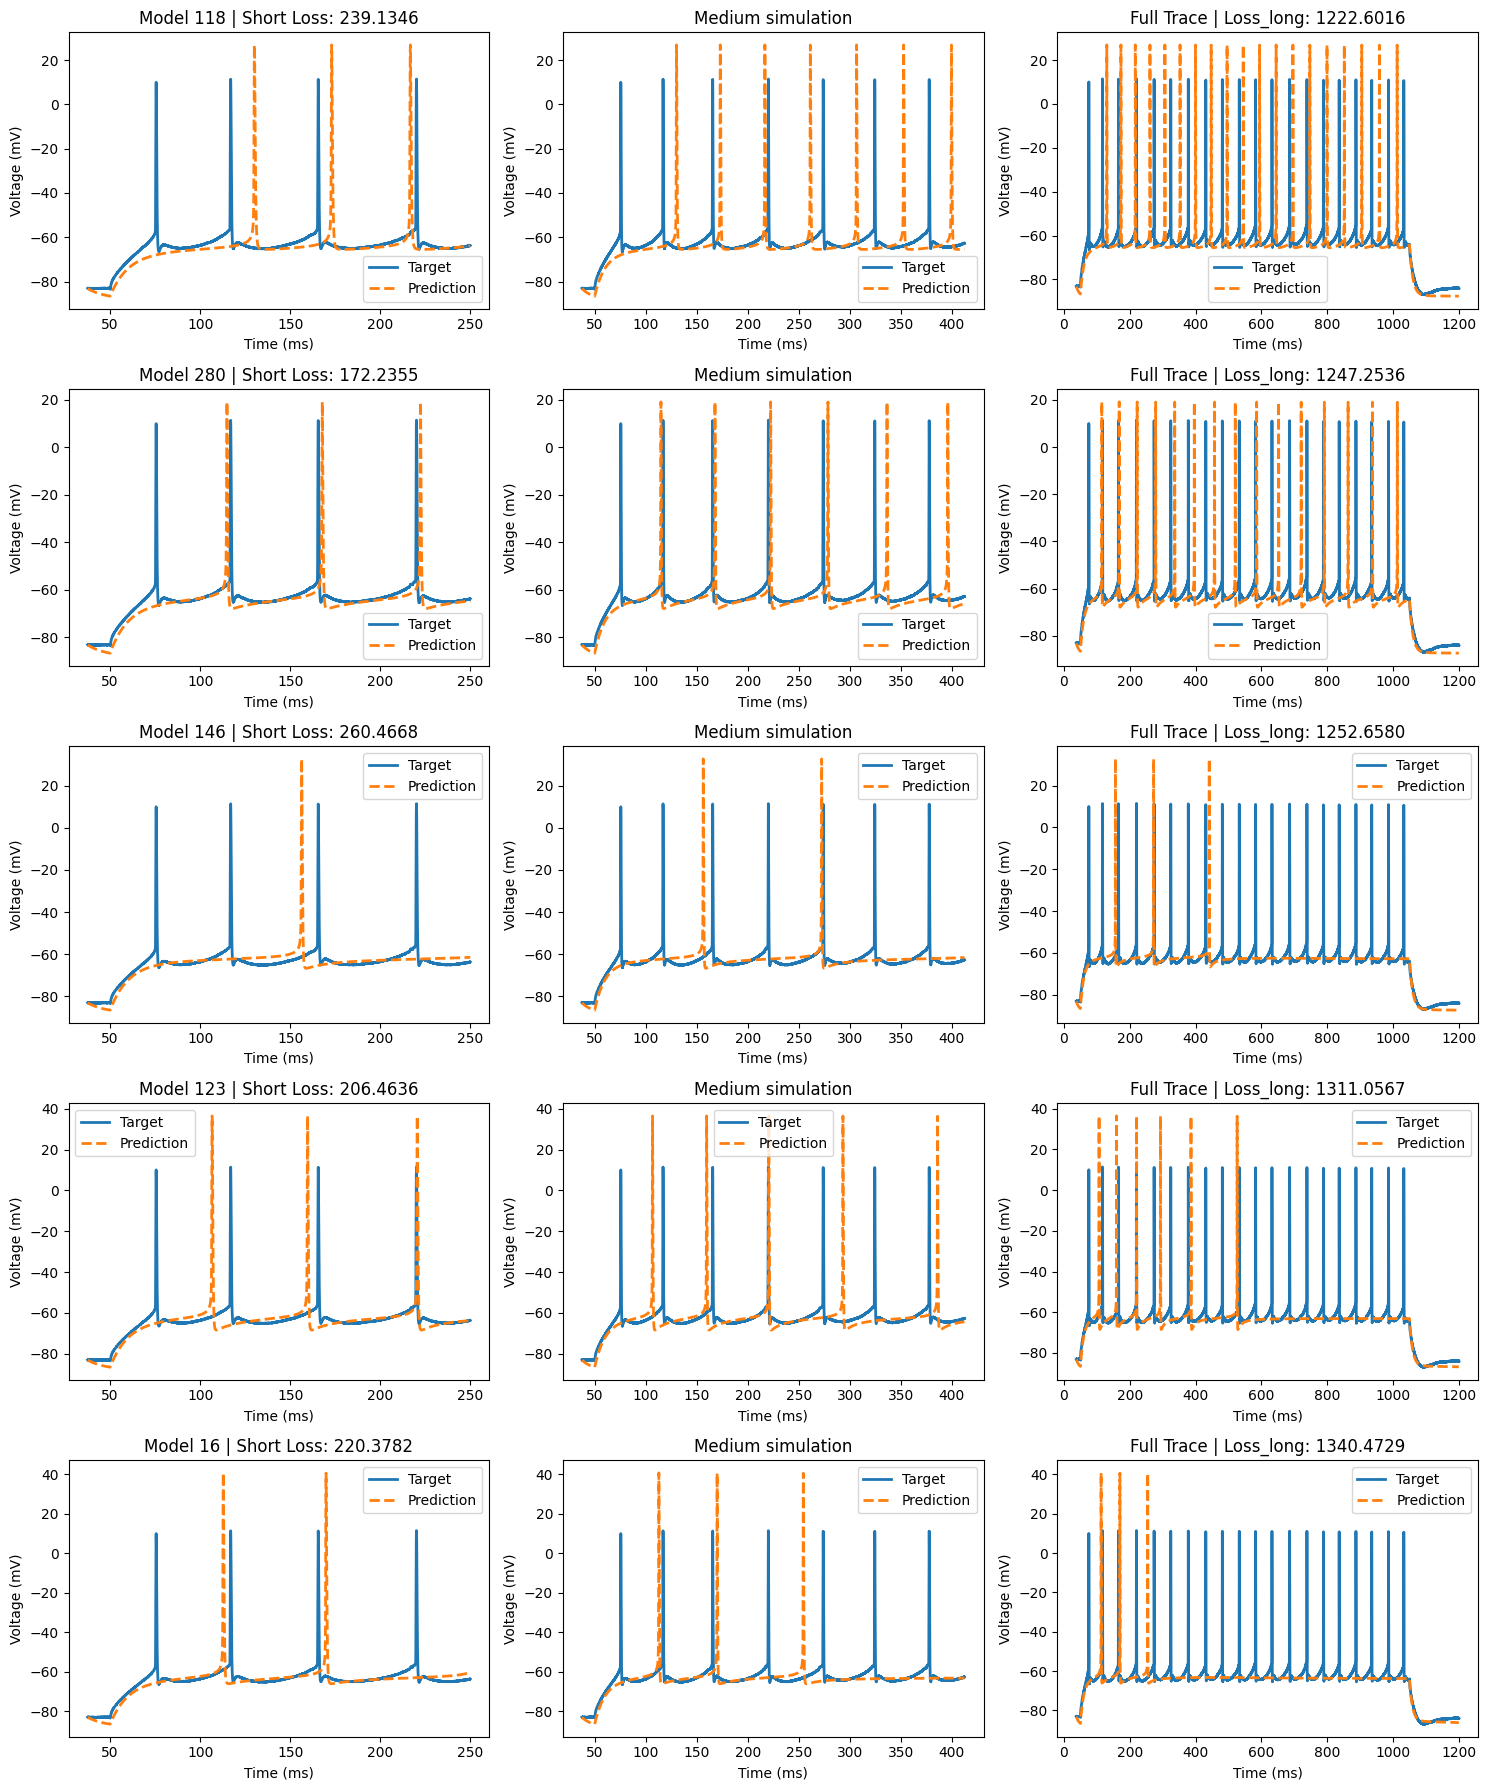

In [ ]:
inds = np.argsort(best_losses)[:20]  # best 20 models

loss_long_list = []
results = []

best_losses_5_long = []
best_preds_5_long = []

for idx in range(20):
    model = jax.tree_util.tree_map(lambda x: x[inds[idx]], best_models)

    opt_inv_params = inv_transform_params(model.channel_params_normal)
    cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

    cell.delete_stimuli()
    cell.delete_recordings()

    current = jx.step_current(50, 1000, i_amp, dt, t_max)
    current = current[cut:]

    cell.stimulate(current, verbose = False)
    cell.record(verbose = False)
    # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
    # cell.soma.branch(0).comp(0).record(verbose = False)
    cell.set("v", all_setup['v_init'])
    cell.init_states()

    # Simulator
    initial_state, step_fn, current, time_vec_long = setup_Na_K_simulator_step(cell, cut, t_max_long, all_setup["v_init"], i_amp, params = opt_inv_params)

    # Run simulation
    final_preds_long = simulate_full_trace(
        initial_state, step_fn, current, time_vec_long, v_data_long.squeeze(), thr
    )

    loss = simulation_loss_fn(model)
    loss_long = get_scaled_loss(v_data_long[0], final_preds_long, cost_fn_power, scale)

    loss_long_list.append(loss_long)
    results.append((loss, loss_long, final_preds_long, time_vec_long, inds[idx]))


# --- Sort by loss_long and take top 5 ---
sorted_results = sorted(results, key=lambda x: x[1])[:5]

fig, axs = plt.subplots(5, 3, figsize=(15, 18))

for row, (loss, loss_long, final_preds_long, time_vec_long, model_idx) in enumerate(sorted_results):
    best_losses_5_long.append(loss_long)
    best_preds_5_long.append(final_preds_long)
    # --- Short trace ---
    axs[row, 0].plot(time_vec_long[:8502], v_data_long[0][:8502], label="Data target", linewidth=2)
    axs[row, 0].plot(time_vec_long[:8502], final_preds_long[:8502], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 0].set_title(f"Model {model_idx} | Short Loss: {loss:.4f}")
    axs[row, 0].set_xlabel("Time (ms)")
    axs[row, 0].set_ylabel("Voltage (mV)")
    axs[row, 0].legend(["Target", "Prediction"])

    # --- Medium trace ---
    axs[row, 1].plot(time_vec_long[:15000], v_data_long[0][:15000], label="Data target", linewidth=2)
    axs[row, 1].plot(time_vec_long[:15000], final_preds_long[:15000], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 1].set_title(f"Medium simulation")
    axs[row, 1].set_xlabel("Time (ms)")
    axs[row, 1].set_ylabel("Voltage (mV)")
    axs[row, 1].legend(["Target", "Prediction"])

    # --- Full trace ---
    axs[row, 2].plot(time_vec_long, v_data_long[0], label="Data target", linewidth=2)
    axs[row, 2].plot(time_vec_long, final_preds_long, label="Prediction", linestyle="--", linewidth=2)
    axs[row, 2].set_title(f"Full Trace | Loss_long: {loss_long:.4f}")
    axs[row, 2].set_xlabel("Time (ms)")
    axs[row, 2].set_ylabel("Voltage (mV)")
    axs[row, 2].legend(["Target", "Prediction"])

plt.tight_layout()
plt.show()

np.save('../results/no_nn_catkm_25_250_long_preds.npy', np.array(best_preds_5_long))
np.save('../results/no_nn_catkm_25_250_long_losses.npy', np.array(best_losses_5_long))

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

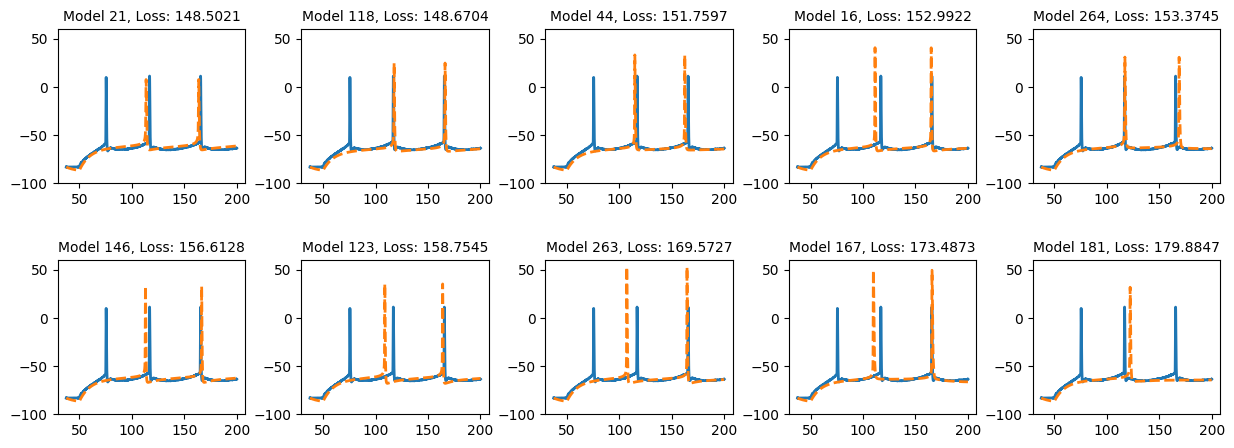

In [ ]:
#25: t = 200.0, CaT + Km
inds = np.argsort(best_losses)

best_losses_10 = []
best_preds_10 = []

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        best_losses_10.append(best_losses[inds[0 + i*5+j]])
        best_preds_10.append(final_preds)
        axs[i,j].plot(time_vec, v_data[0], label="Eexperimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)


np.save('../results/no_nn_catkm_25_200_preds.npy', np.array(best_preds_10))
np.save('../results/no_nn_catkm_25_200_losses.npy', np.array(best_losses_10))
np.save('../results/v_data_25_200.npy', np.array(v_data))

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

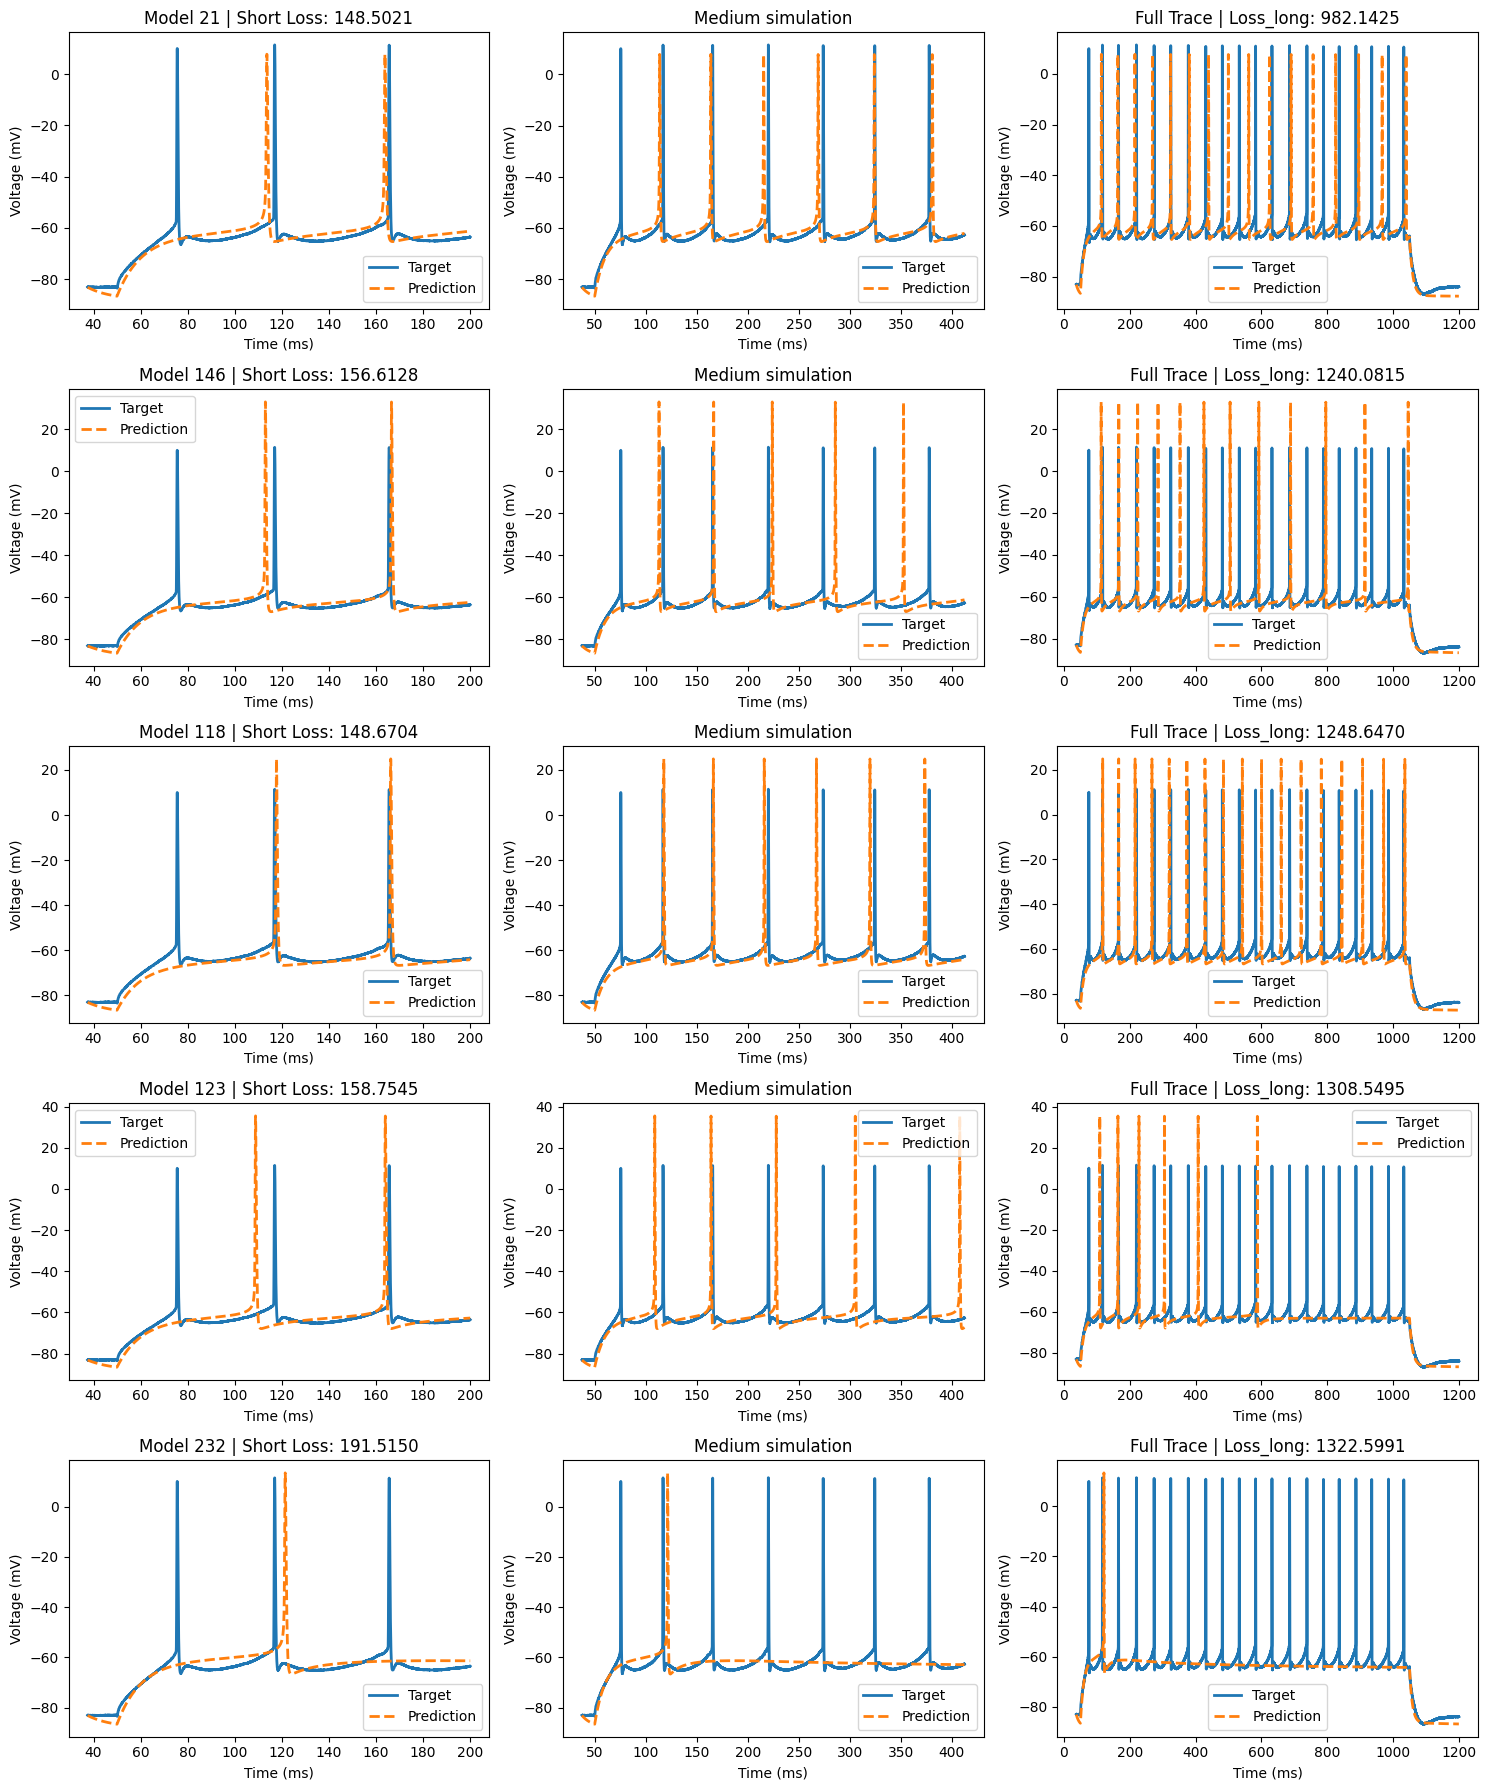

In [ ]:
inds = np.argsort(best_losses)[:20]  # best 20 models

loss_long_list = []
results = []

best_losses_5_long = []
best_preds_5_long = []

for idx in range(20):
    model = jax.tree_util.tree_map(lambda x: x[inds[idx]], best_models)

    opt_inv_params = inv_transform_params(model.channel_params_normal)
    cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

    cell.delete_stimuli()
    cell.delete_recordings()

    current = jx.step_current(50, 1000, i_amp, dt, t_max)
    current = current[cut:]

    cell.stimulate(current, verbose = False)
    cell.record(verbose = False)
    # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
    # cell.soma.branch(0).comp(0).record(verbose = False)
    cell.set("v", all_setup['v_init'])
    cell.init_states()

    # Simulator
    initial_state, step_fn, current, time_vec_long = setup_Na_K_simulator_step(cell, cut, t_max_long, all_setup["v_init"], i_amp, params = opt_inv_params)

    # Run simulation
    final_preds_long = simulate_full_trace(
        initial_state, step_fn, current, time_vec_long, v_data_long.squeeze(), thr
    )

    loss = simulation_loss_fn(model)
    loss_long = get_scaled_loss(v_data_long[0], final_preds_long, cost_fn_power, scale)

    loss_long_list.append(loss_long)
    results.append((loss, loss_long, final_preds_long, time_vec_long, inds[idx]))


# --- Sort by loss_long and take top 5 ---
sorted_results = sorted(results, key=lambda x: x[1])[:5]

fig, axs = plt.subplots(5, 3, figsize=(15, 18))

for row, (loss, loss_long, final_preds_long, time_vec_long, model_idx) in enumerate(sorted_results):
    best_losses_5_long.append(loss_long)
    best_preds_5_long.append(final_preds_long)
    # --- Short trace ---
    axs[row, 0].plot(time_vec_long[:6502], v_data_long[0][:6502], label="Data target", linewidth=2)
    axs[row, 0].plot(time_vec_long[:6502], final_preds_long[:6502], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 0].set_title(f"Model {model_idx} | Short Loss: {loss:.4f}")
    axs[row, 0].set_xlabel("Time (ms)")
    axs[row, 0].set_ylabel("Voltage (mV)")
    axs[row, 0].legend(["Target", "Prediction"])

    # --- Medium trace ---
    axs[row, 1].plot(time_vec_long[:15000], v_data_long[0][:15000], label="Data target", linewidth=2)
    axs[row, 1].plot(time_vec_long[:15000], final_preds_long[:15000], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 1].set_title(f"Medium simulation")
    axs[row, 1].set_xlabel("Time (ms)")
    axs[row, 1].set_ylabel("Voltage (mV)")
    axs[row, 1].legend(["Target", "Prediction"])

    # --- Full trace ---
    axs[row, 2].plot(time_vec_long, v_data_long[0], label="Data target", linewidth=2)
    axs[row, 2].plot(time_vec_long, final_preds_long, label="Prediction", linestyle="--", linewidth=2)
    axs[row, 2].set_title(f"Full Trace | Loss_long: {loss_long:.4f}")
    axs[row, 2].set_xlabel("Time (ms)")
    axs[row, 2].set_ylabel("Voltage (mV)")
    axs[row, 2].legend(["Target", "Prediction"])

plt.tight_layout()
plt.show()

np.save('../results/no_nn_catkm_25_200_long_preds.npy', np.array(best_preds_5_long))
np.save('../results/no_nn_catkm_25_200_long_losses.npy', np.array(best_losses_5_long))

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

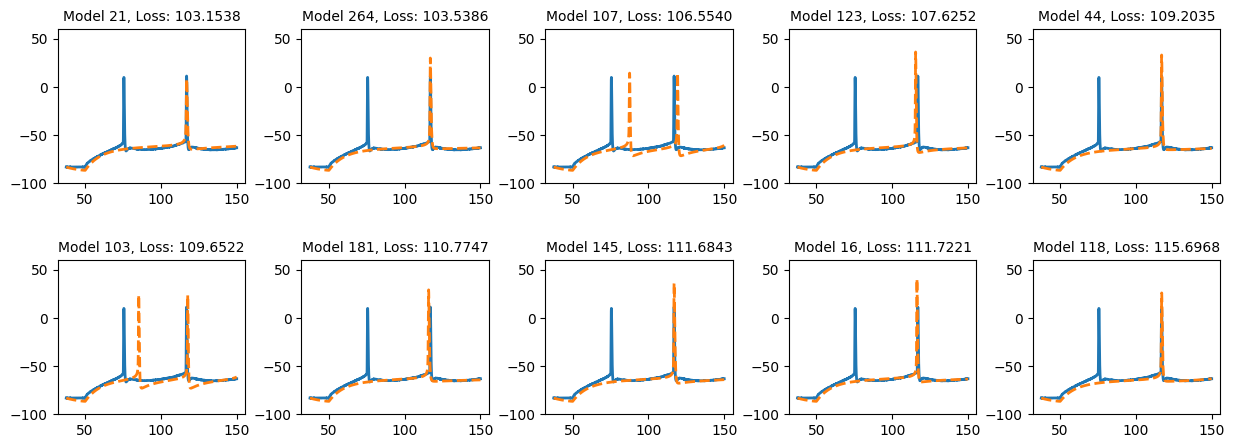

In [ ]:
#25: t = 150.0, CaT + Km
inds = np.argsort(best_losses)

best_losses_10 = []
best_preds_10 = []

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        best_losses_10.append(best_losses[inds[0 + i*5+j]])
        best_preds_10.append(final_preds)
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)


np.save('../results/no_nn_catkm_25_150_preds.npy', np.array(best_preds_10))
np.save('../results/no_nn_catkm_25_150_losses.npy', np.array(best_losses_10))
np.save('../results/v_data_25_150.npy', np.array(v_data))

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

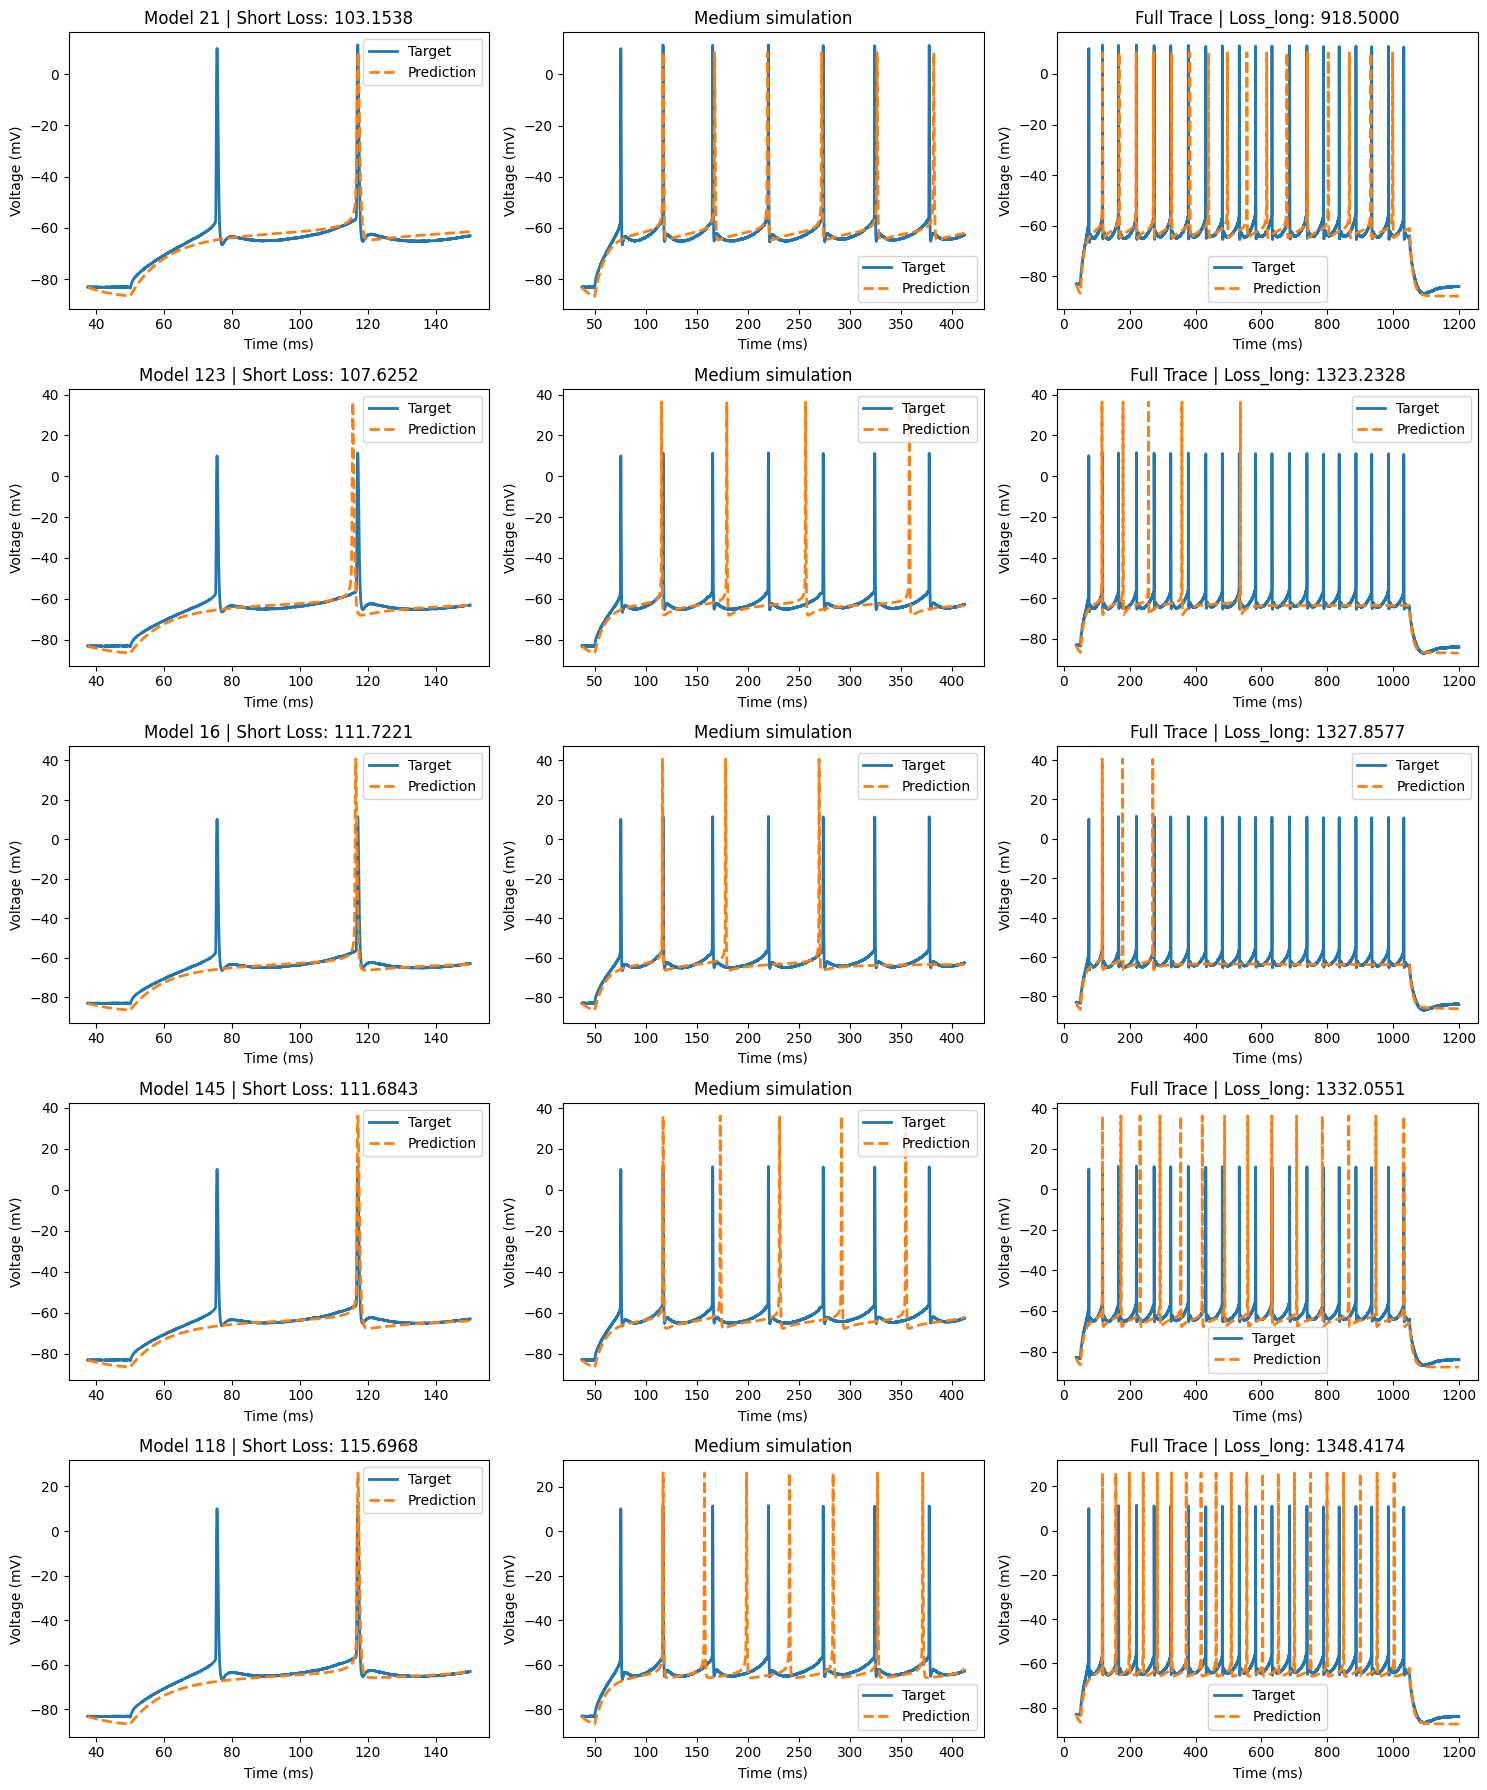

In [ ]:
inds = np.argsort(best_losses)[:20]  # best 20 models

loss_long_list = []
results = []

best_losses_5_long = []
best_preds_5_long = []

for idx in range(20):
    model = jax.tree_util.tree_map(lambda x: x[inds[idx]], best_models)

    opt_inv_params = inv_transform_params(model.channel_params_normal)
    cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

    cell.delete_stimuli()
    cell.delete_recordings()

    current = jx.step_current(50, 1000, i_amp, dt, t_max)
    current = current[cut:]

    cell.stimulate(current, verbose = False)
    cell.record(verbose = False)
    # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
    # cell.soma.branch(0).comp(0).record(verbose = False)
    cell.set("v", all_setup['v_init'])
    cell.init_states()

    # Simulator
    initial_state, step_fn, current, time_vec_long = setup_Na_K_simulator_step(cell, cut, t_max_long, all_setup["v_init"], i_amp, params = opt_inv_params)

    # Run simulation
    final_preds_long = simulate_full_trace(
        initial_state, step_fn, current, time_vec_long, v_data_long.squeeze(), thr
    )

    loss = simulation_loss_fn(model)
    loss_long = get_scaled_loss(v_data_long[0], final_preds_long, cost_fn_power, scale)

    loss_long_list.append(loss_long)
    results.append((loss, loss_long, final_preds_long, time_vec_long, inds[idx]))


# --- Sort by loss_long and take top 5 ---
sorted_results = sorted(results, key=lambda x: x[1])[:5]

fig, axs = plt.subplots(5, 3, figsize=(15, 18))

for row, (loss, loss_long, final_preds_long, time_vec_long, model_idx) in enumerate(sorted_results):
    best_losses_5_long.append(loss_long)
    best_preds_5_long.append(final_preds_long)
    # --- Short trace ---
    axs[row, 0].plot(time_vec_long[:4502], v_data_long[0][:4502], label="Data target", linewidth=2)
    axs[row, 0].plot(time_vec_long[:4502], final_preds_long[:4502], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 0].set_title(f"Model {model_idx} | Short Loss: {loss:.4f}")
    axs[row, 0].set_xlabel("Time (ms)")
    axs[row, 0].set_ylabel("Voltage (mV)")
    axs[row, 0].legend(["Target", "Prediction"])

    # --- Medium trace ---
    axs[row, 1].plot(time_vec_long[:15000], v_data_long[0][:15000], label="Data target", linewidth=2)
    axs[row, 1].plot(time_vec_long[:15000], final_preds_long[:15000], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 1].set_title(f"Medium simulation")
    axs[row, 1].set_xlabel("Time (ms)")
    axs[row, 1].set_ylabel("Voltage (mV)")
    axs[row, 1].legend(["Target", "Prediction"])

    # --- Full trace ---
    axs[row, 2].plot(time_vec_long, v_data_long[0], label="Data target", linewidth=2)
    axs[row, 2].plot(time_vec_long, final_preds_long, label="Prediction", linestyle="--", linewidth=2)
    axs[row, 2].set_title(f"Full Trace | Loss_long: {loss_long:.4f}")
    axs[row, 2].set_xlabel("Time (ms)")
    axs[row, 2].set_ylabel("Voltage (mV)")
    axs[row, 2].legend(["Target", "Prediction"])

plt.tight_layout()
plt.show()

np.save('../results/no_nn_catkm_25_150_long_preds.npy', np.array(best_preds_5_long))
np.save('../results/no_nn_catkm_25_150_long_losses.npy', np.array(best_losses_5_long))

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

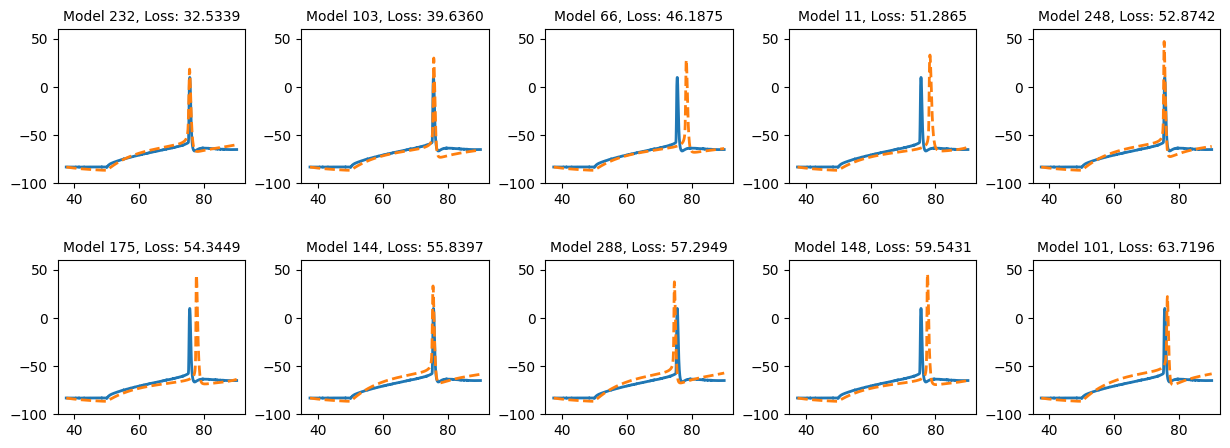

In [ ]:
#25: t = 90.0, CaT + Km
inds = np.argsort(best_losses)

best_losses_10 = []
best_preds_10 = []

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        best_losses_10.append(best_losses[inds[0 + i*5+j]])
        best_preds_10.append(final_preds)
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)


np.save('../results/no_nn_catkm_25_90_preds.npy', np.array(best_preds_10))
np.save('../results/no_nn_catkm_25_90_losses.npy', np.array(best_losses_10))
np.save('../results/v_data_25_90.npy', np.array(v_data))

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

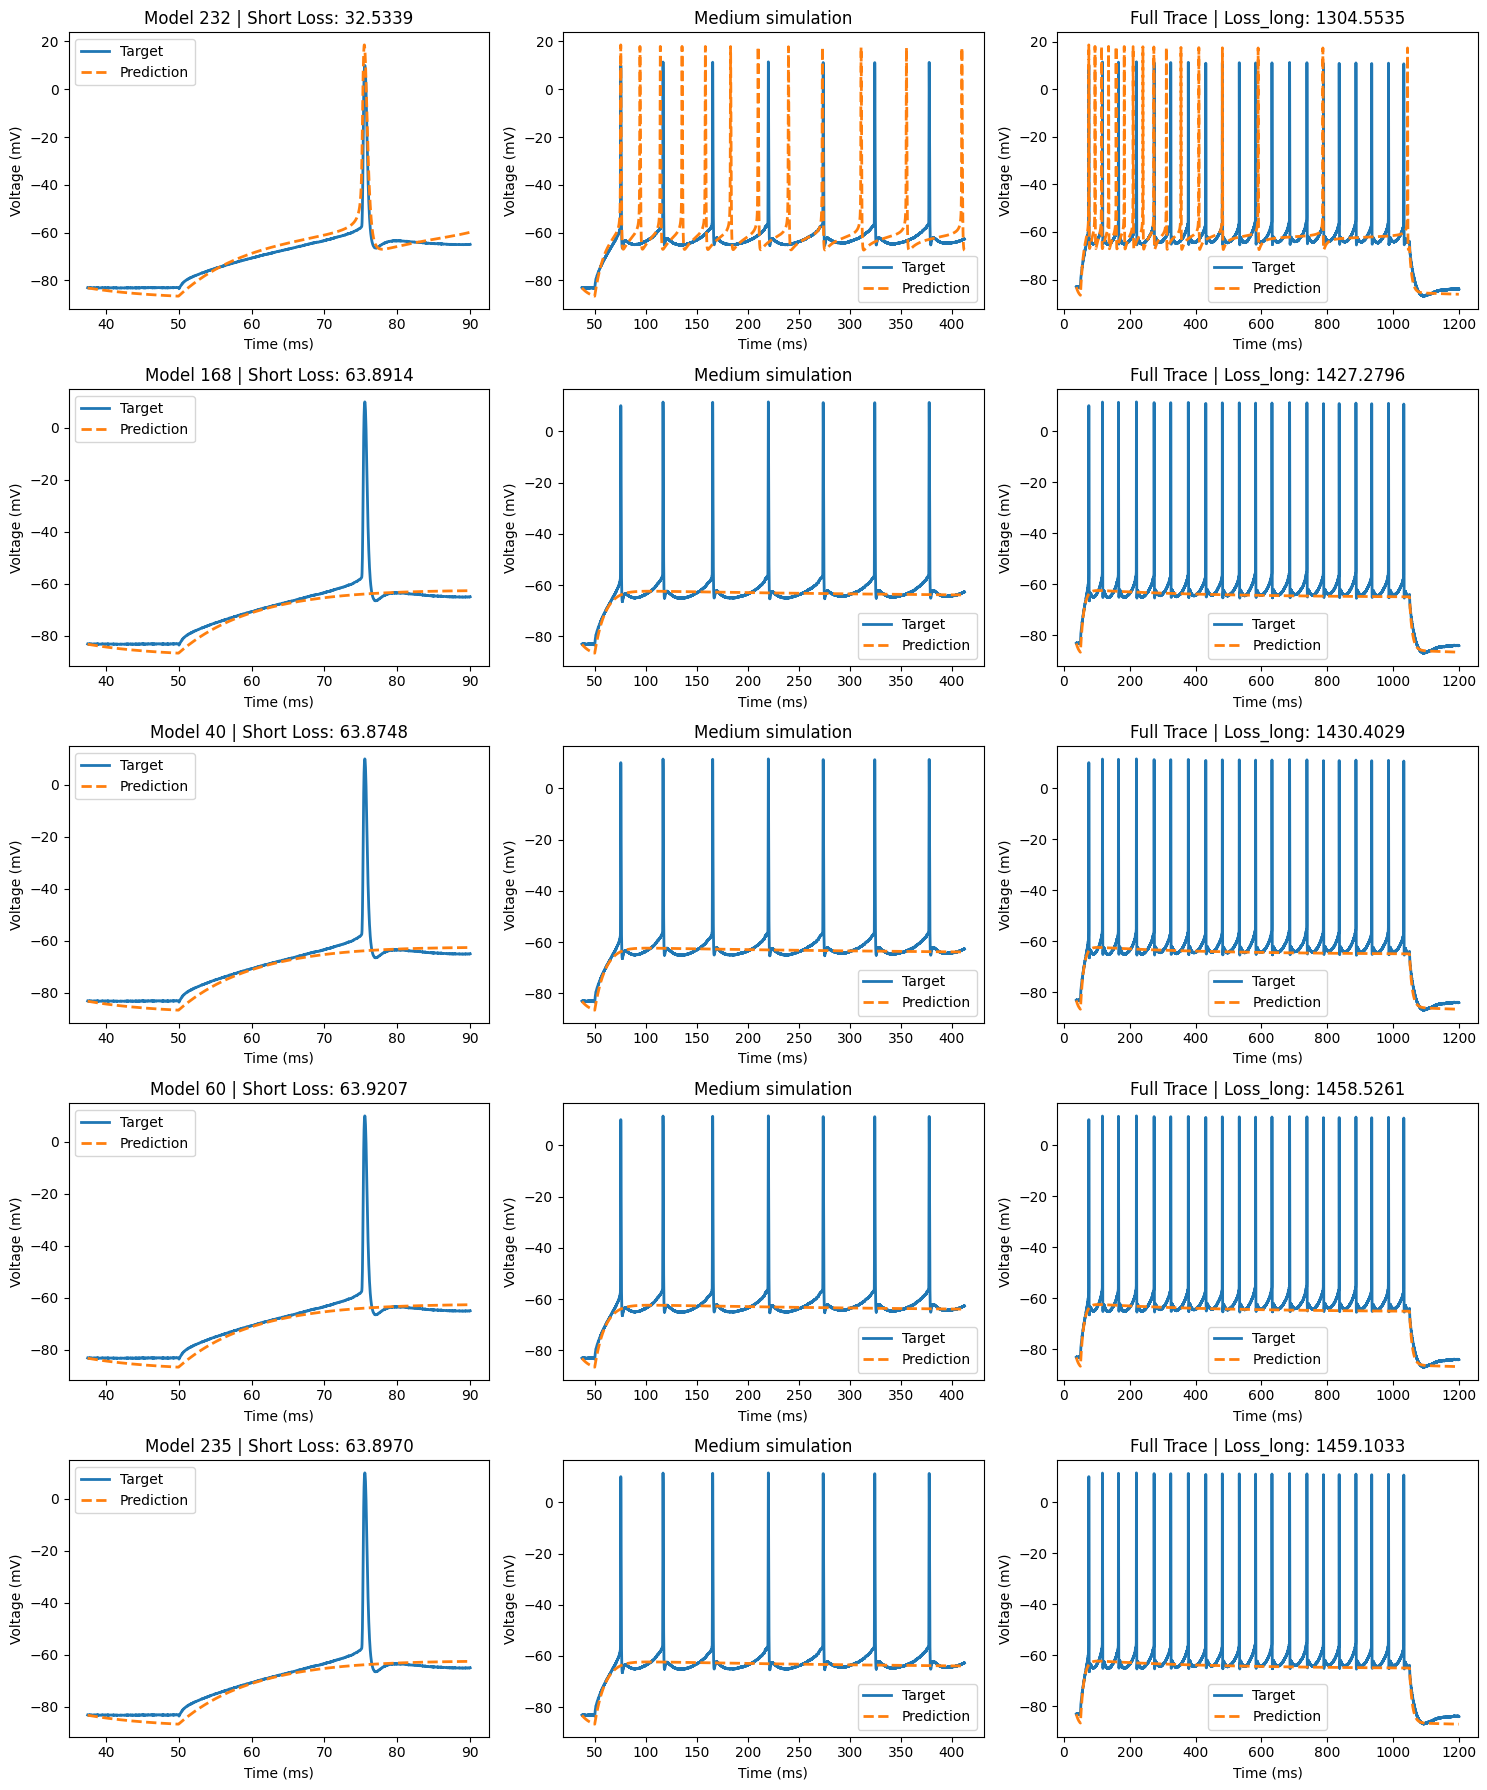

In [ ]:
inds = np.argsort(best_losses)[:20]  # best 20 models

loss_long_list = []
results = []

best_losses_5_long = []
best_preds_5_long = []

for idx in range(20):
    model = jax.tree_util.tree_map(lambda x: x[inds[idx]], best_models)

    opt_inv_params = inv_transform_params(model.channel_params_normal)
    cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

    cell.delete_stimuli()
    cell.delete_recordings()

    current = jx.step_current(50, 1000, i_amp, dt, t_max)
    current = current[cut:]

    cell.stimulate(current, verbose = False)
    cell.record(verbose = False)
    # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
    # cell.soma.branch(0).comp(0).record(verbose = False)
    cell.set("v", all_setup['v_init'])
    cell.init_states()

    # Simulator
    initial_state, step_fn, current, time_vec_long = setup_Na_K_simulator_step(cell, cut, t_max_long, all_setup["v_init"], i_amp, params = opt_inv_params)

    # Run simulation
    final_preds_long = simulate_full_trace(
        initial_state, step_fn, current, time_vec_long, v_data_long.squeeze(), thr
    )

    loss = simulation_loss_fn(model)
    loss_long = get_scaled_loss(v_data_long[0], final_preds_long, cost_fn_power, scale)

    loss_long_list.append(loss_long)
    results.append((loss, loss_long, final_preds_long, time_vec_long, inds[idx]))


# --- Sort by loss_long and take top 5 ---
sorted_results = sorted(results, key=lambda x: x[1])[:5]

fig, axs = plt.subplots(5, 3, figsize=(15, 18))

for row, (loss, loss_long, final_preds_long, time_vec_long, model_idx) in enumerate(sorted_results):
    best_losses_5_long.append(loss_long)
    best_preds_5_long.append(final_preds_long)
    # --- Short trace ---
    axs[row, 0].plot(time_vec_long[:2102], v_data_long[0][:2102], label="Data target", linewidth=2)
    axs[row, 0].plot(time_vec_long[:2102], final_preds_long[:2102], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 0].set_title(f"Model {model_idx} | Short Loss: {loss:.4f}")
    axs[row, 0].set_xlabel("Time (ms)")
    axs[row, 0].set_ylabel("Voltage (mV)")
    axs[row, 0].legend(["Target", "Prediction"])

    # --- Medium trace ---
    axs[row, 1].plot(time_vec_long[:15000], v_data_long[0][:15000], label="Data target", linewidth=2)
    axs[row, 1].plot(time_vec_long[:15000], final_preds_long[:15000], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 1].set_title(f"Medium simulation")
    axs[row, 1].set_xlabel("Time (ms)")
    axs[row, 1].set_ylabel("Voltage (mV)")
    axs[row, 1].legend(["Target", "Prediction"])

    # --- Full trace ---
    axs[row, 2].plot(time_vec_long, v_data_long[0], label="Data target", linewidth=2)
    axs[row, 2].plot(time_vec_long, final_preds_long, label="Prediction", linestyle="--", linewidth=2)
    axs[row, 2].set_title(f"Full Trace | Loss_long: {loss_long:.4f}")
    axs[row, 2].set_xlabel("Time (ms)")
    axs[row, 2].set_ylabel("Voltage (mV)")
    axs[row, 2].legend(["Target", "Prediction"])

plt.tight_layout()
plt.show()

np.save('../results/no_nn_catkm_25_90_long_preds.npy', np.array(best_preds_5_long))
np.save('../results/no_nn_catkm_25_90_long_losses.npy', np.array(best_losses_5_long))

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

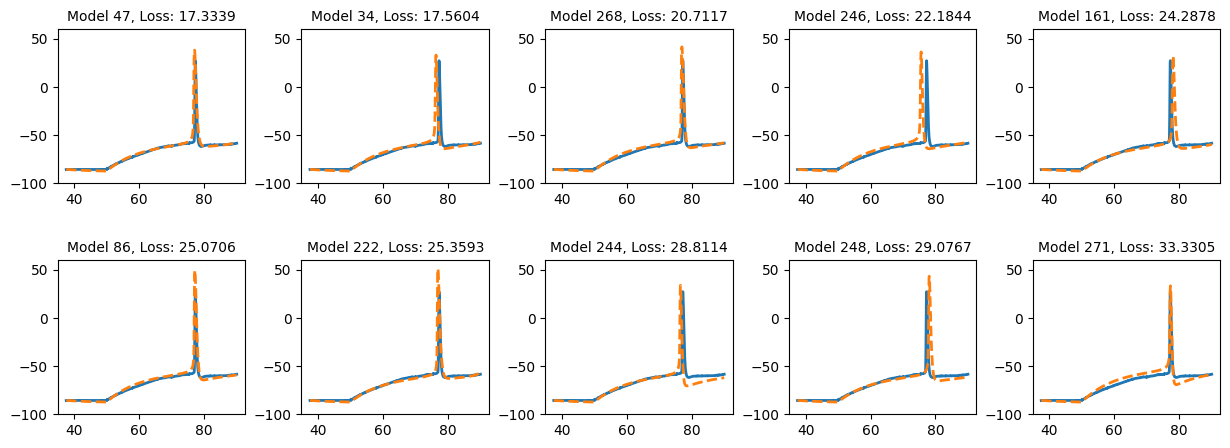

In [ ]:
#32: t = 90.0, CaT + Km
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

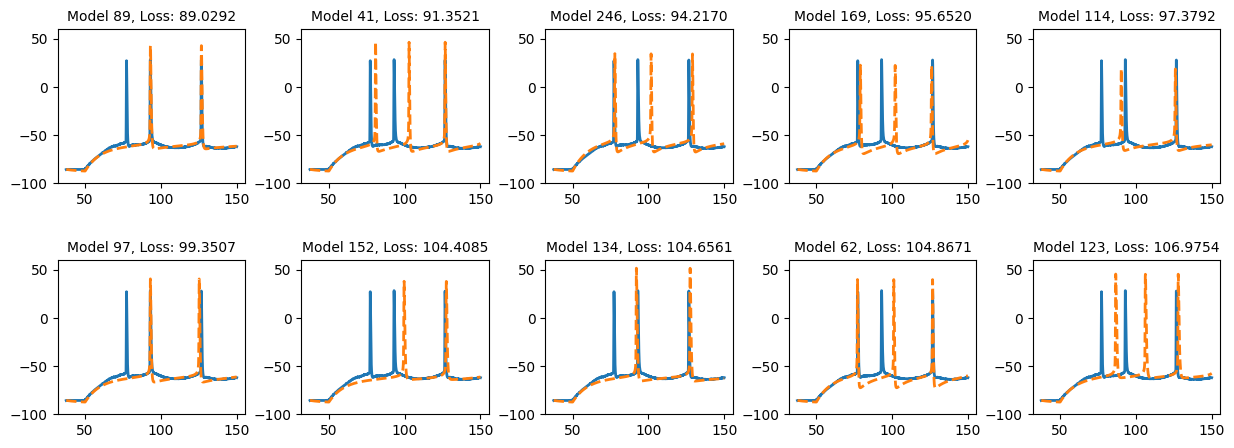

In [ ]:
#32: t = 150.0, CaT + Km
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

Extrapolation:

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

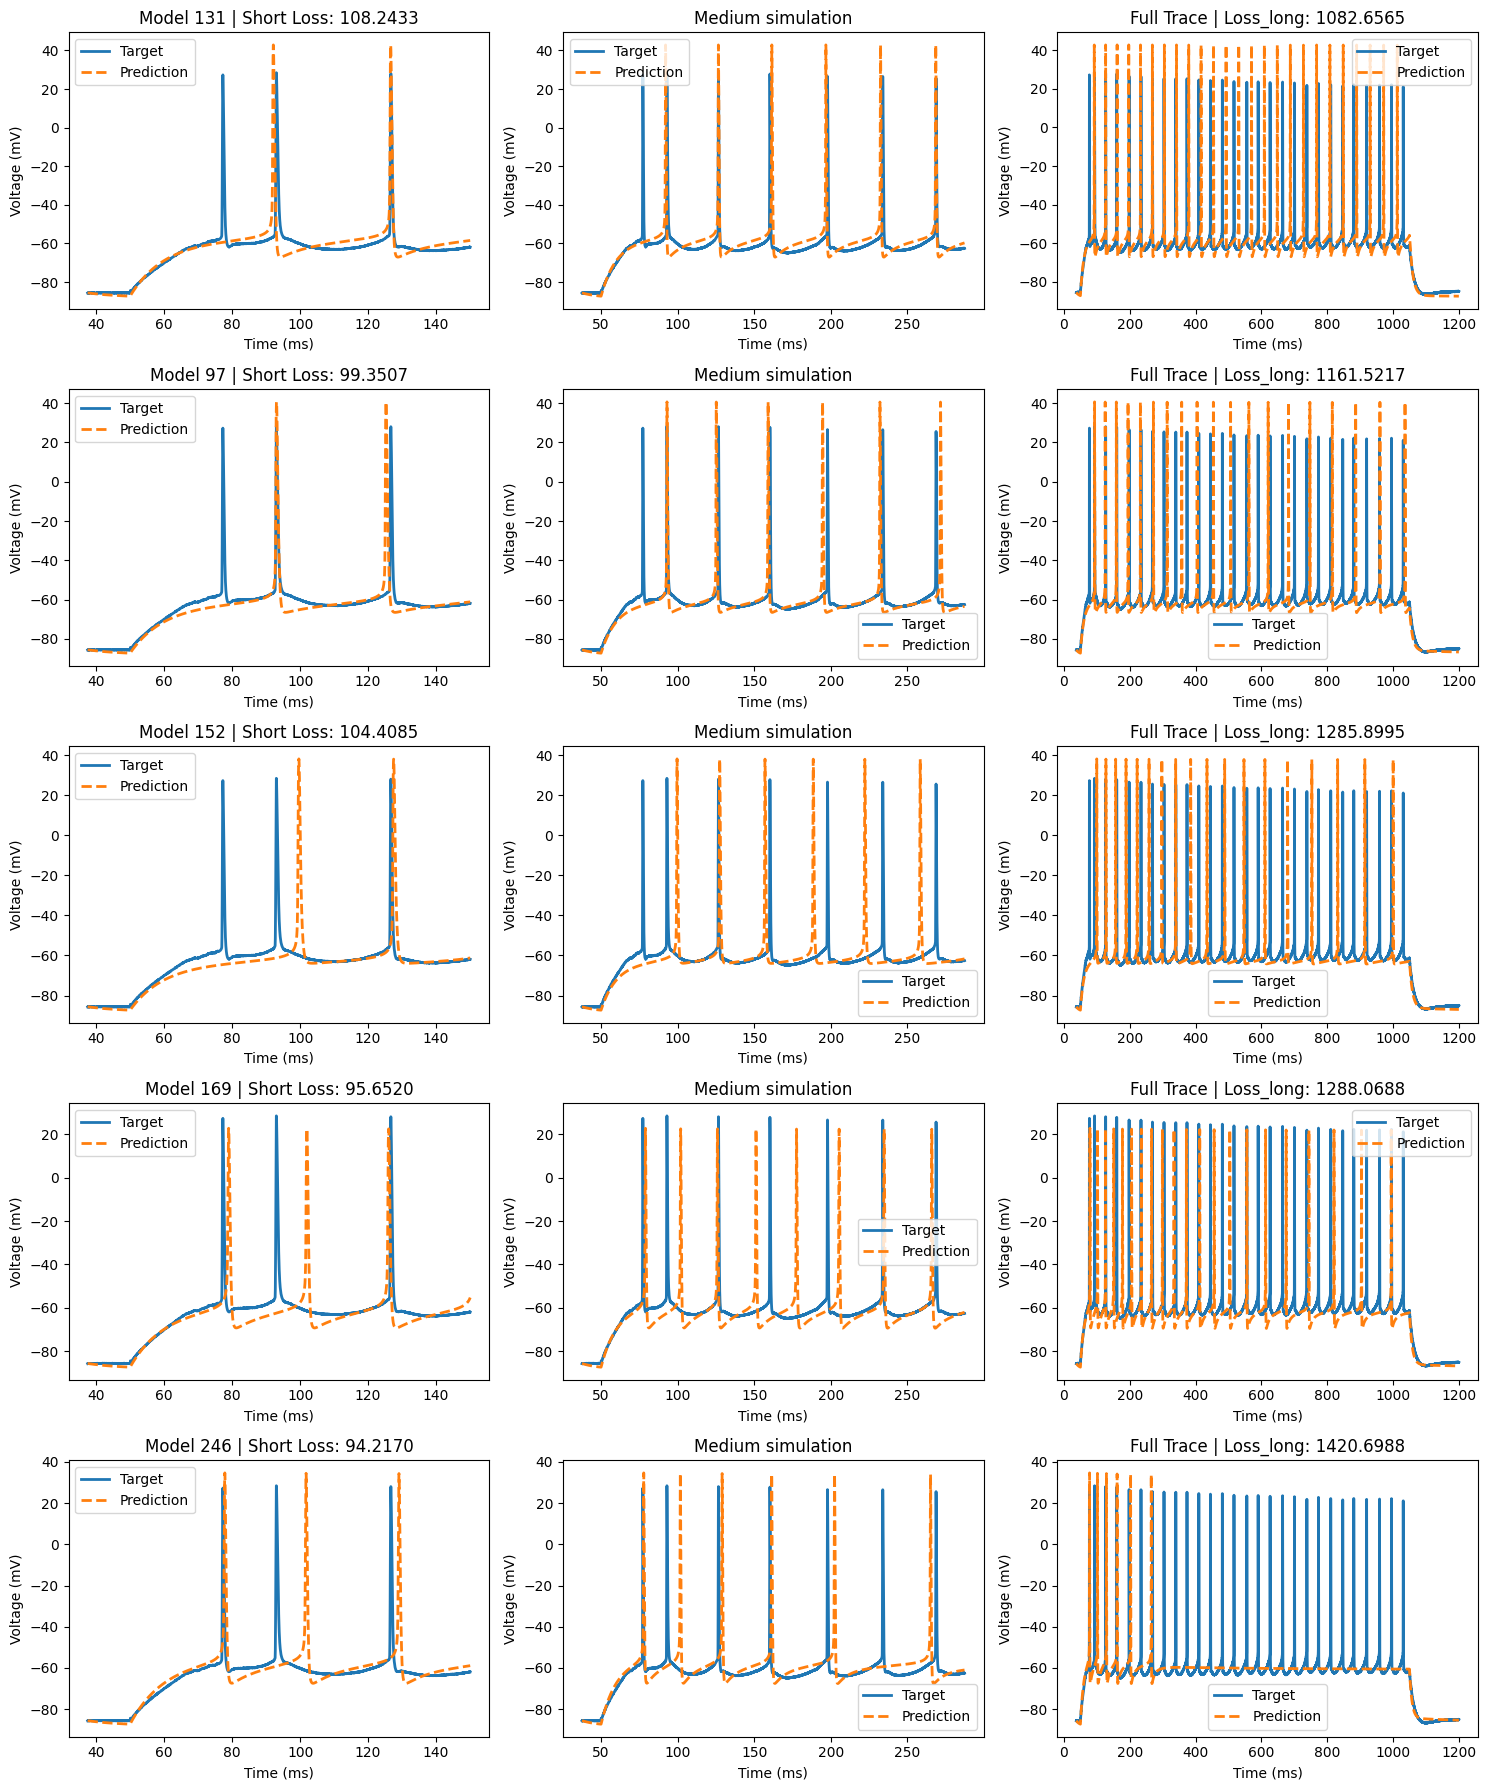

In [ ]:
inds = np.argsort(best_losses)[:20]  # best 20 models

loss_long_list = []
results = []

for idx in range(20):
    model = jax.tree_util.tree_map(lambda x: x[inds[idx]], best_models)

    opt_inv_params = inv_transform_params(model.channel_params_normal)
    cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

    cell.delete_stimuli()
    cell.delete_recordings()

    current = jx.step_current(50, 1000, i_amp, dt, t_max)
    current = current[cut:]

    cell.stimulate(current, verbose = False)
    cell.record(verbose = False)
    # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
    # cell.soma.branch(0).comp(0).record(verbose = False)
    cell.set("v", all_setup['v_init'])
    cell.init_states()

    # Simulator
    initial_state, step_fn, current, time_vec_long = setup_Na_K_simulator_step(cell, cut, t_max_long, all_setup["v_init"], i_amp, params = opt_inv_params)

    # Run simulation
    final_preds_long = simulate_full_trace(
        initial_state, step_fn, current, time_vec_long, v_data_long.squeeze(), thr
    )

    loss = simulation_loss_fn(model)
    loss_long = get_scaled_loss(v_data_long[0], final_preds_long, cost_fn_power, scale)

    loss_long_list.append(loss_long)
    results.append((loss, loss_long, final_preds_long, time_vec_long, inds[idx]))

# --- Sort by loss_long and take top 5 ---
sorted_results = sorted(results, key=lambda x: x[1])[:5]

fig, axs = plt.subplots(5, 3, figsize=(15, 18))

for row, (loss, loss_long, final_preds_long, time_vec_long, model_idx) in enumerate(sorted_results):
    # --- Short trace ---
    axs[row, 0].plot(time_vec_long[:4502], v_data_long[0][:4502], label="Data target", linewidth=2)
    axs[row, 0].plot(time_vec_long[:4502], final_preds_long[:4502], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 0].set_title(f"Model {model_idx} | Short Loss: {loss:.4f}")
    axs[row, 0].set_xlabel("Time (ms)")
    axs[row, 0].set_ylabel("Voltage (mV)")
    axs[row, 0].legend(["Target", "Prediction"])

    # --- Medium trace ---
    axs[row, 1].plot(time_vec_long[:10000], v_data_long[0][:10000], label="Data target", linewidth=2)
    axs[row, 1].plot(time_vec_long[:10000], final_preds_long[:10000], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 1].set_title(f"Medium simulation")
    axs[row, 1].set_xlabel("Time (ms)")
    axs[row, 1].set_ylabel("Voltage (mV)")
    axs[row, 1].legend(["Target", "Prediction"])

    # --- Full trace ---
    axs[row, 2].plot(time_vec_long, v_data_long[0], label="Data target", linewidth=2)
    axs[row, 2].plot(time_vec_long, final_preds_long, label="Prediction", linestyle="--", linewidth=2)
    axs[row, 2].set_title(f"Full Trace | Loss_long: {loss_long:.4f}")
    axs[row, 2].set_xlabel("Time (ms)")
    axs[row, 2].set_ylabel("Voltage (mV)")
    axs[row, 2].legend(["Target", "Prediction"])

plt.tight_layout()
plt.show()

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

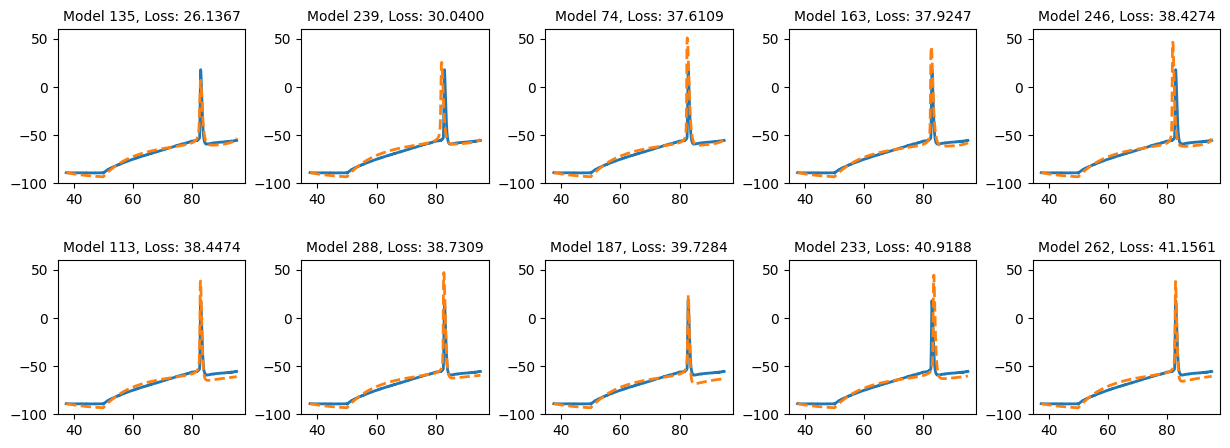

In [ ]:
#86: t = 95.0, CaT + Km
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

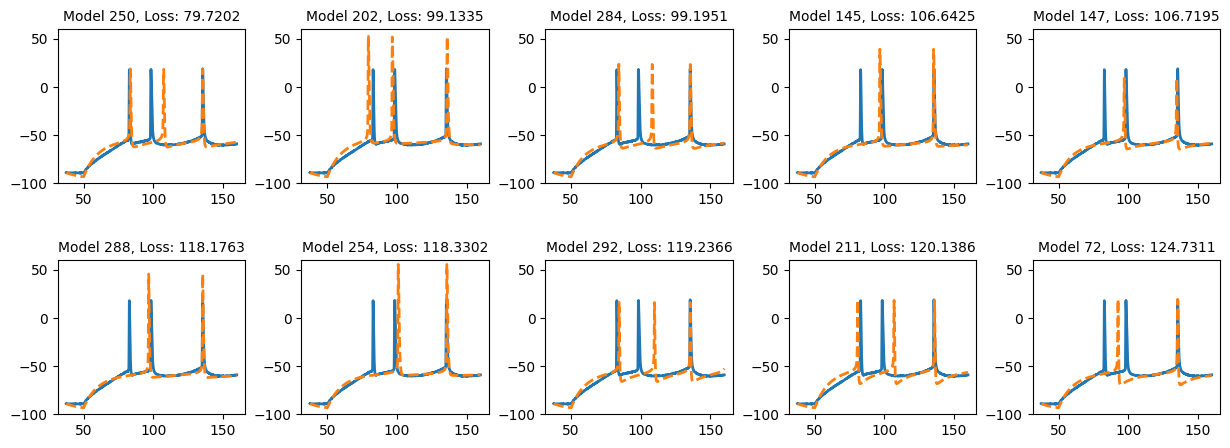

In [ ]:
#86: t = 160.0, CaT + Km
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

Extrapolation:

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

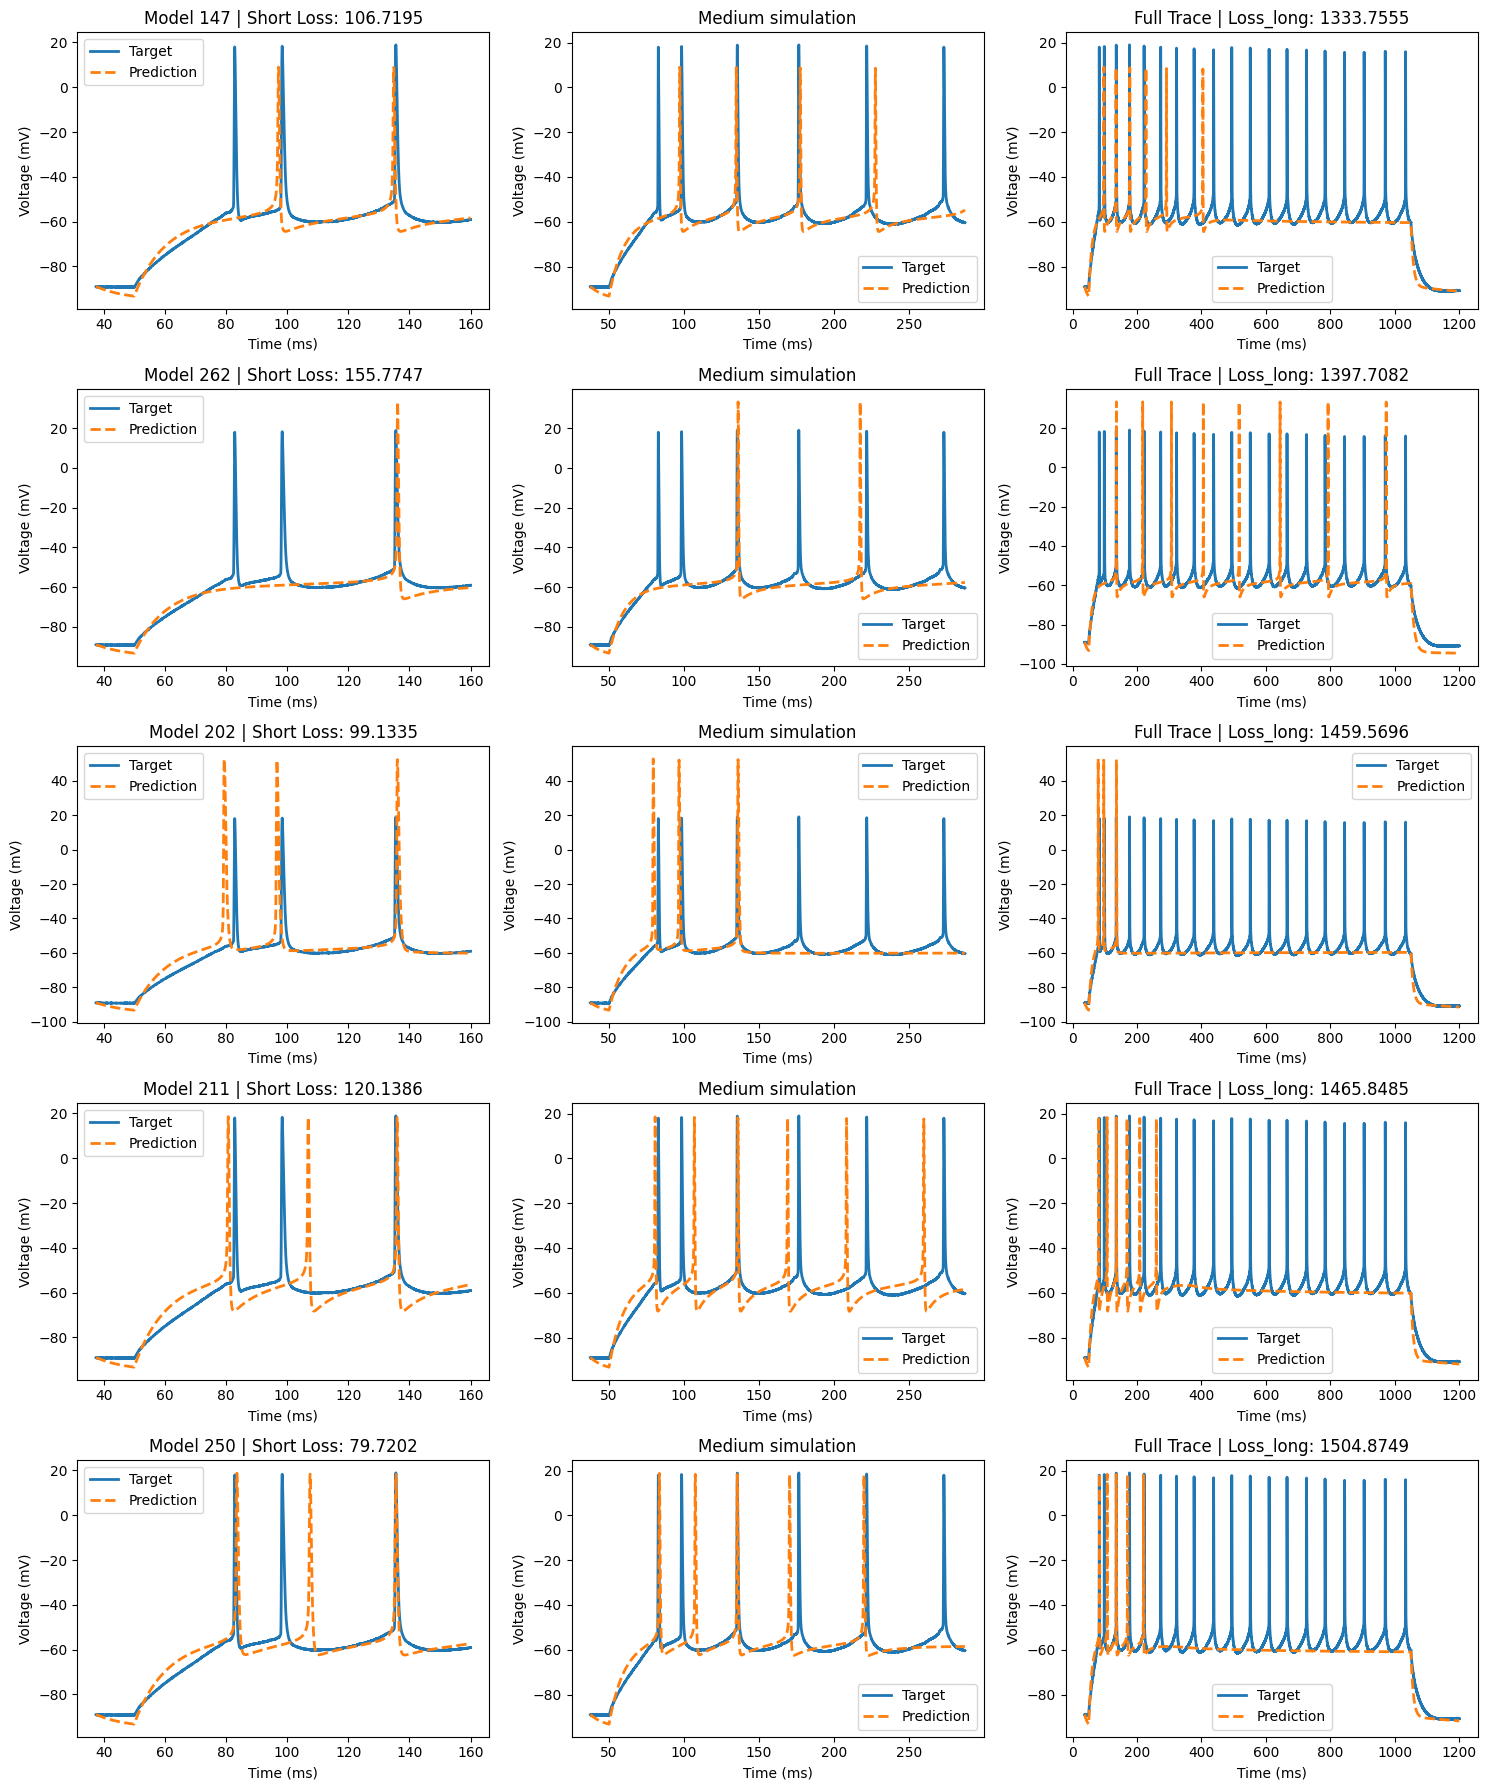

In [ ]:
inds = np.argsort(best_losses)[:20]  # best 20 models

loss_long_list = []
results = []

for idx in range(20):
    model = jax.tree_util.tree_map(lambda x: x[inds[idx]], best_models)

    opt_inv_params = inv_transform_params(model.channel_params_normal)
    cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

    cell.delete_stimuli()
    cell.delete_recordings()

    current = jx.step_current(50, 1000, i_amp, dt, t_max)
    current = current[cut:]

    cell.stimulate(current, verbose = False)
    cell.record(verbose = False)
    # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
    # cell.soma.branch(0).comp(0).record(verbose = False)
    cell.set("v", all_setup['v_init'])
    cell.init_states()

    # Simulator
    initial_state, step_fn, current, time_vec_long = setup_Na_K_simulator_step(cell, cut, t_max_long, all_setup["v_init"], i_amp, params = opt_inv_params)

    # Run simulation
    final_preds_long = simulate_full_trace(
        initial_state, step_fn, current, time_vec_long, v_data_long.squeeze(), thr
    )

    loss = simulation_loss_fn(model)
    loss_long = get_scaled_loss(v_data_long[0], final_preds_long, cost_fn_power, scale)

    loss_long_list.append(loss_long)
    results.append((loss, loss_long, final_preds_long, time_vec_long, inds[idx]))

# --- Sort by loss_long and take top 5 ---
sorted_results = sorted(results, key=lambda x: x[1])[:5]

fig, axs = plt.subplots(5, 3, figsize=(15, 18))

for row, (loss, loss_long, final_preds_long, time_vec_long, model_idx) in enumerate(sorted_results):
    # --- Short trace ---
    axs[row, 0].plot(time_vec_long[:4902], v_data_long[0][:4902], label="Data target", linewidth=2)
    axs[row, 0].plot(time_vec_long[:4902], final_preds_long[:4902], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 0].set_title(f"Model {model_idx} | Short Loss: {loss:.4f}")
    axs[row, 0].set_xlabel("Time (ms)")
    axs[row, 0].set_ylabel("Voltage (mV)")
    axs[row, 0].legend(["Target", "Prediction"])

    # --- Medium trace ---
    axs[row, 1].plot(time_vec_long[:10000], v_data_long[0][:10000], label="Data target", linewidth=2)
    axs[row, 1].plot(time_vec_long[:10000], final_preds_long[:10000], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 1].set_title(f"Medium simulation")
    axs[row, 1].set_xlabel("Time (ms)")
    axs[row, 1].set_ylabel("Voltage (mV)")
    axs[row, 1].legend(["Target", "Prediction"])

    # --- Full trace ---
    axs[row, 2].plot(time_vec_long, v_data_long[0], label="Data target", linewidth=2)
    axs[row, 2].plot(time_vec_long, final_preds_long, label="Prediction", linestyle="--", linewidth=2)
    axs[row, 2].set_title(f"Full Trace | Loss_long: {loss_long:.4f}")
    axs[row, 2].set_xlabel("Time (ms)")
    axs[row, 2].set_ylabel("Voltage (mV)")
    axs[row, 2].legend(["Target", "Prediction"])

plt.tight_layout()
plt.show()

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

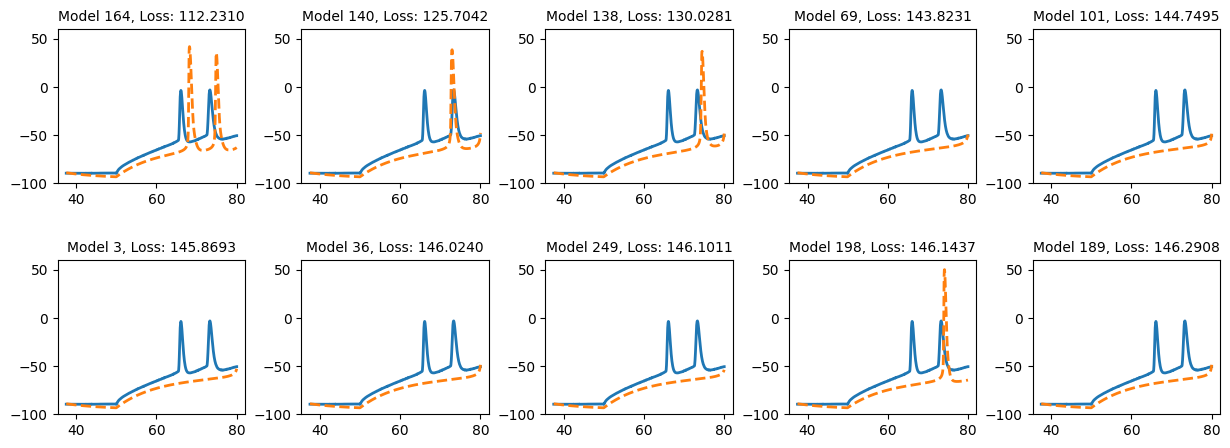

In [ ]:
#79: t = 80.0, CaT + Km
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

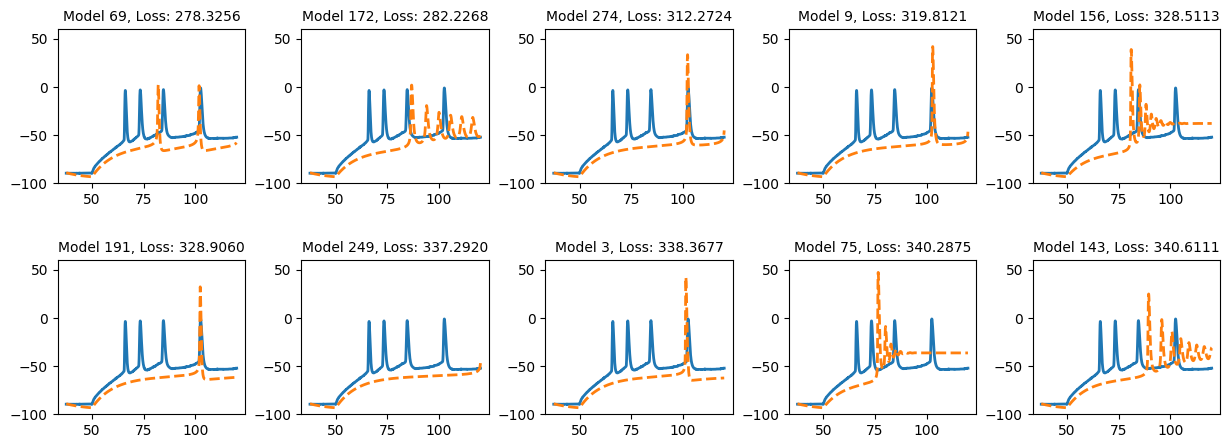

In [ ]:
#79: t = 120.0, CaT + Km
inds = np.argsort(best_losses)

fig, axs = plt.subplots(2,5, figsize = (15,5))
fig.subplots_adjust(hspace=0.5, wspace=0.3)
for i in range(2):
    for j in range(5):
        model = jax.tree_util.tree_map(lambda x: x[inds[0 + i*5+j]], best_models)
        opt_inv_params = inv_transform_params(model.channel_params_normal)

        # Rebuild the simulator with new cell
        cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

        cell.delete_stimuli()
        cell.delete_recordings()

        current = jx.step_current(50, 1000, i_amp, dt, t_max)
        current = current[cut:]

        cell.stimulate(current, verbose = False)
        cell.record(verbose = False)
        # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
        # cell.soma.branch(0).comp(0).record(verbose = False)
        cell.set("v", all_setup['v_init'])
        cell.init_states()
        
        initial_state, step_fn, current, time_vec = setup_Na_K_simulator_step(cell, cut, t_max, all_setup["v_init"], i_amp, params = opt_inv_params)

        # Run simulation
        final_preds = simulate_full_trace(
            initial_state, step_fn, current, time_vec, v_data.squeeze(), thr
        )
        axs[i,j].plot(time_vec, v_data[0], label="Experimental target", linewidth=2)
        axs[i,j].plot(time_vec, final_preds, label="Single-compartment prediction", linestyle="--", linewidth=2)
        axs[i,j].set_title(f"Model {inds[i*5+j]}, Loss: {best_losses[inds[i*5+j]]:.4f}", fontsize = 10)
        axs[i,j].set_ylim(-100, 60)

/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  self.base.nodes.loc[self._nodes_in_view, key] = channel.channel_params[key]
/Users/moldor/Documents/Thesis/jaxley/jaxley/modules/base.py:1843: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of callin

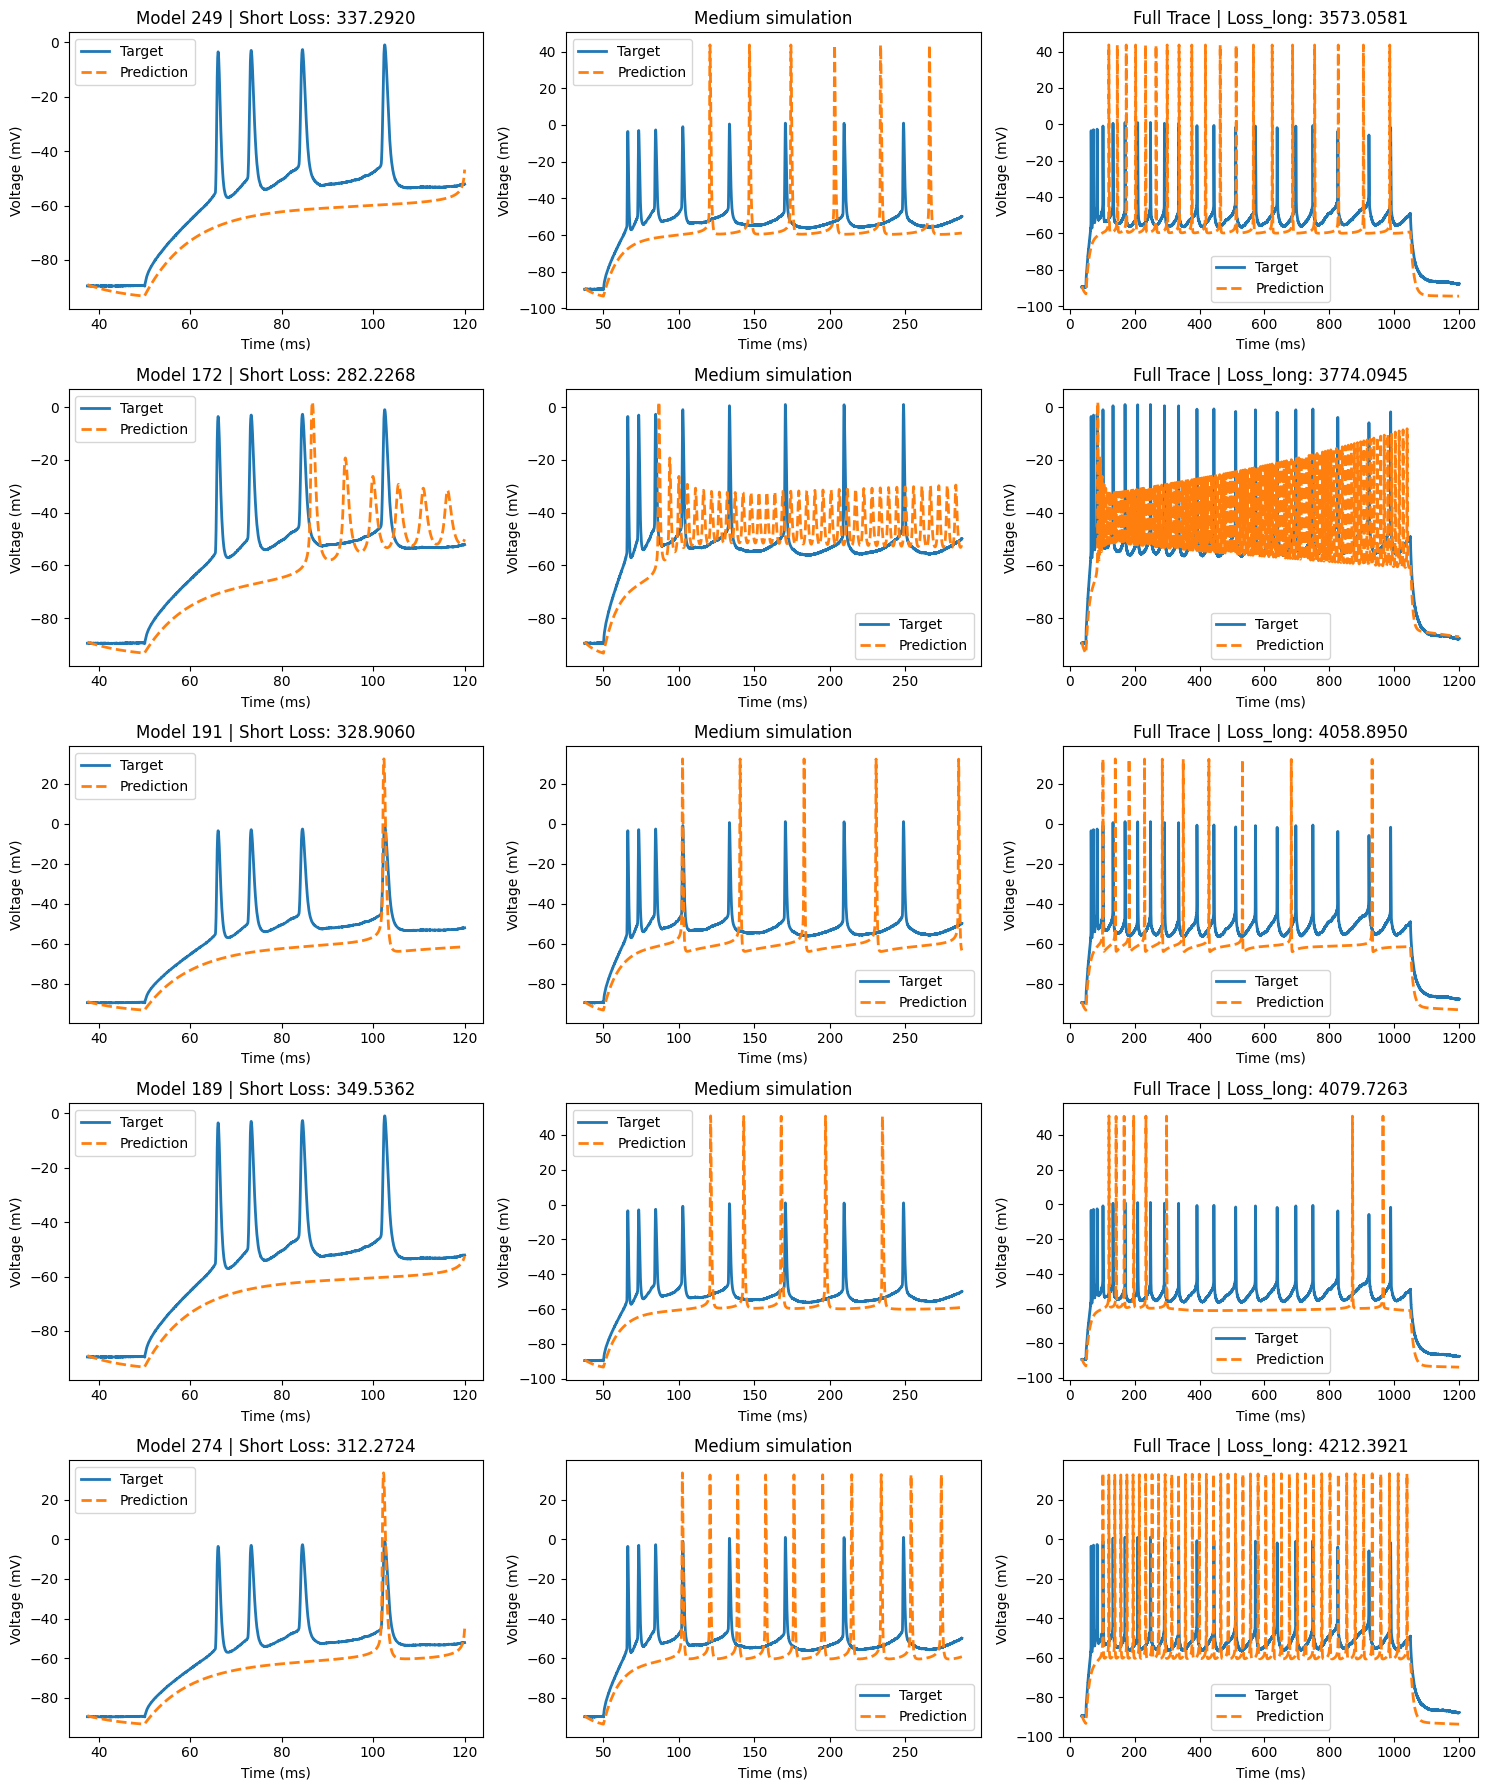

In [ ]:
inds = np.argsort(best_losses)[:20]  # best 20 models

loss_long_list = []
results = []

for idx in range(20):
    model = jax.tree_util.tree_map(lambda x: x[inds[idx]], best_models)

    opt_inv_params = inv_transform_params(model.channel_params_normal)
    cell = build_Na_K_cell(all_setup['capacitance'], all_setup["eleak"], all_setup['gleak'], all_setup['length'], use_CaT=True, use_CaL=False, use_Km=True)

    cell.delete_stimuli()
    cell.delete_recordings()

    current = jx.step_current(50, 1000, i_amp, dt, t_max)
    current = current[cut:]

    cell.stimulate(current, verbose = False)
    cell.record(verbose = False)
    # cell.soma.branch(0).comp(0).stimulate(current, verbose = False)
    # cell.soma.branch(0).comp(0).record(verbose = False)
    cell.set("v", all_setup['v_init'])
    cell.init_states()

    # Simulator
    initial_state, step_fn, current, time_vec_long = setup_Na_K_simulator_step(cell, cut, t_max_long, all_setup["v_init"], i_amp, params = opt_inv_params)

    # Run simulation
    final_preds_long = simulate_full_trace(
        initial_state, step_fn, current, time_vec_long, v_data_long.squeeze(), thr
    )

    loss = simulation_loss_fn(model)
    loss_long = get_scaled_loss(v_data_long[0], final_preds_long, cost_fn_power, scale)

    loss_long_list.append(loss_long)
    results.append((loss, loss_long, final_preds_long, time_vec_long, inds[idx]))

# --- Sort by loss_long and take top 5 ---
sorted_results = sorted(results, key=lambda x: x[1])[:5]

fig, axs = plt.subplots(5, 3, figsize=(15, 18))

for row, (loss, loss_long, final_preds_long, time_vec_long, model_idx) in enumerate(sorted_results):
    # --- Short trace ---
    axs[row, 0].plot(time_vec_long[:3302], v_data_long[0][:3302], label="Data target", linewidth=2)
    axs[row, 0].plot(time_vec_long[:3302], final_preds_long[:3302], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 0].set_title(f"Model {model_idx} | Short Loss: {loss:.4f}")
    axs[row, 0].set_xlabel("Time (ms)")
    axs[row, 0].set_ylabel("Voltage (mV)")
    axs[row, 0].legend(["Target", "Prediction"])

    # --- Medium trace ---
    axs[row, 1].plot(time_vec_long[:10000], v_data_long[0][:10000], label="Data target", linewidth=2)
    axs[row, 1].plot(time_vec_long[:10000], final_preds_long[:10000], label="Prediction", linestyle="--", linewidth=2)
    axs[row, 1].set_title(f"Medium simulation")
    axs[row, 1].set_xlabel("Time (ms)")
    axs[row, 1].set_ylabel("Voltage (mV)")
    axs[row, 1].legend(["Target", "Prediction"])

    # --- Full trace ---
    axs[row, 2].plot(time_vec_long, v_data_long[0], label="Data target", linewidth=2)
    axs[row, 2].plot(time_vec_long, final_preds_long, label="Prediction", linestyle="--", linewidth=2)
    axs[row, 2].set_title(f"Full Trace | Loss_long: {loss_long:.4f}")
    axs[row, 2].set_xlabel("Time (ms)")
    axs[row, 2].set_ylabel("Voltage (mV)")
    axs[row, 2].legend(["Target", "Prediction"])

plt.tight_layout()
plt.show()